In [5]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch.distributions import MultivariateNormal
import math

from moc.metrics.distribution_metrics import calculate_PIT, pce

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"

from moc.configs.config import get_config
from moc.utils.run_config import RunConfig
from moc.models.mixture.mixture_model2 import MixtureLightningModule
from moc.models.gaussian.gaussian import GaussianLightningModule
from moc.models.trainers.lightning_trainer import get_lightning_trainer
from moc.datamodules.real_datamodule import RealDataModule
from moc.metrics.distribution_metrics import pce, multivariate_energy_score, mse
from pathlib import Path
import glob

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Utilities ---

In [137]:
preranks_map = {
    "mean": "Location",
    "marginal": "Marginal",
    "pca": "PCA",
    "density": "HDR",
    "dependency": "Dependency",
    "variance": "Scale",
    # "cdf": "Copula"
}

In [ ]:
def exp_cov_1d(d: int, sigma2: float = 1.0, tau: float = 1.0, device=device):
    """
    Exponential covariance on indices 1..d:
      Σ_ij = sigma2 * exp(-|i-j|/tau)
    """
    idx = torch.arange(d, device=device, dtype=torch.float32)
    dist = (idx[:, None] - idx[None, :]).abs()
    return sigma2 * torch.exp(-dist / tau)

def make_mvn(mean, cov):
    mean_t = torch.tensor(mean, dtype=torch.float32, device=device)
    cov_t = torch.tensor(cov, dtype=torch.float32, device=device)
    return torch.distributions.MultivariateNormal(mean_t, covariance_matrix=cov_t)

def sample_truth_and_ensemble(dist_true, dist_pred, N: int, M: int):
    """
    Returns:
      y: (N, d) observations
      x: (N, M, d) ensemble members
    """
    y = dist_true.sample((N,))
    x = dist_pred.sample((N, M))
    return y, x

def grid_points(p: int, q: int, device=device):
    """Return (d, 2) coordinates for a p×q grid, d=p*q."""
    xs = torch.arange(p, device=device, dtype=torch.float32)
    ys = torch.arange(q, device=device, dtype=torch.float32)
    X, Y = torch.meshgrid(xs, ys, indexing="ij")
    coords = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=1)
    return coords  # (p*q, 2)

def exp_cov_euclid(coords, sigma2=1.0, tau=1.0):
    """
    Exponential covariance on coordinates:
      Σ_ij = sigma2 * exp(-||s_i - s_j|| / tau)
    """
    diff = coords[:, None, :] - coords[None, :, :]
    dist = torch.sqrt((diff ** 2).sum(dim=-1))
    return sigma2 * torch.exp(-dist / tau)

def exp_cov_euclid_aniso(coords, sigma2=1.0, tau=1.0, y_scale=1.25):
    """
    Geometric anisotropy: rescale y-axis before distance.
      distance((x,y),(x',y')) = sqrt((x-x')^2 + (y_scale*(y-y'))^2)
    """
    c = coords.clone()
    c[:, 1] = y_scale * c[:, 1]
    return exp_cov_euclid(c, sigma2=sigma2, tau=tau)

In [139]:
def cov_from(sigma=1.0, rho=0.6, device=device):
    s2 = float(sigma) ** 2
    return torch.tensor([[s2, rho * s2],
                         [rho * s2, s2]], dtype=torch.float32, device=device)

def make_batch_mvn(mu, cov, N, device=device):
    """
    mu: shape (2,) tensor or list
    cov: shape (2,2) tensor
    returns MultivariateNormal with batch shape (N,) and event shape (2,)
    """
    mu = torch.tensor(mu, dtype=torch.float32, device=device) if not torch.is_tensor(mu) else mu.to(device)
    cov = cov.to(device)

    mu_b = mu.expand(N, -1)           # (N,2)
    cov_b = cov.expand(N, -1, -1)     # (N,2,2)
    return torch.distributions.MultivariateNormal(mu_b, covariance_matrix=cov_b)

### We add PC rotated : we keep eigenvalues the same as the true covariance but rotates eigenvectors.

In [140]:
def cov_rotated_same_spectrum(rho_true=0.6, theta_deg=30, device=device):
    # eigenvalues of [[1,rho],[rho,1]]
    lam1 = 1.0 + rho_true
    lam2 = 1.0 - rho_true
    theta = np.deg2rad(theta_deg)

    c = float(np.cos(theta))
    s = float(np.sin(theta))

    Q = torch.tensor([[c, -s],
                      [s,  c]], dtype=torch.float32, device=device)
    Lam = torch.tensor([[lam1, 0.0],
                        [0.0, lam2]], dtype=torch.float32, device=device)

    Sigma = Q @ Lam @ Q.T
    return Sigma


def compute_pits_for_case(mu_pred, cov_pred, N, y, n_samples, prerank):
    dist_pred = make_batch_mvn(mu_pred, cov_pred, N, device=device)
    pit_values, explained_var = calculate_PIT(dist_pred, y, n_samples=n_samples, prerank=prerank, setup="real")
    return pit_values.squeeze(-1)

def plot_pit_hist(ax, pits_1d, title="", bins=50):
    pits = pits_1d.detach().cpu().numpy()
    ax.hist(pits, bins=bins, range=(0,1), density=True, edgecolor="white")
    ax.axhline(1.0, linestyle="--", linewidth=1, color="red")
    ax.set_xlim(0, 1)
    ax.set_title(title, fontsize=9)
    ax.set_ylim(0, 3.0)
    ax.set_yticks([0, 0.5, 3.0])
    ax.set_xticks([0, 0.5, 1.0])

In [141]:
def rotate_covariance_pc12(cov, theta_deg):
    """
    Rotate covariance matrix in the plane of its first two eigenvectors.
    Preserves eigenvalues, rotates leading PCs by angle theta.

    cov: (d,d) SPD tensor
    theta_deg: rotation angle in degrees
    """
    device = cov.device
    d = cov.shape[0]

    # Eigendecomposition (sorted descending)
    eigvals, eigvecs = torch.linalg.eigh(cov)
    idx = torch.argsort(eigvals, descending=True)
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]  # columns = eigenvectors

    # Rotation in the (PC1, PC2) subspace
    theta = torch.tensor(theta_deg * torch.pi / 180, device=device)
    c, s = torch.cos(theta), torch.sin(theta)

    R2 = torch.tensor([[c, -s],
                       [s,  c]], device=device)

    # Build block rotation matrix in eigenbasis
    R = torch.eye(d, device=device)
    R[:2, :2] = R2

    # Rotate eigenvectors
    eigvecs_rot = eigvecs @ R

    # Reconstruct covariance
    cov_rot = eigvecs_rot @ torch.diag(eigvals) @ eigvecs_rot.T
    return cov_rot


In [142]:
def cov_pc_energy_swap(cov, k=1):
    """
    Take a SPD covariance 'cov' (d x d).
    Swap the largest k eigenvalues with the smallest k eigenvalues.
    Returns a new SPD covariance with same eigenvectors but
    variance 'energy' moved into the 'wrong' modes.
    """
    device = cov.device
    d = cov.shape[0]

    # eigvals sorted ascending by torch.linalg.eigh
    eigvals, eigvecs = torch.linalg.eigh(cov)
    # sort descending for convenience
    idx = torch.argsort(eigvals, descending=True)
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    new_eigvals = eigvals.clone()

    # swap top k with bottom k
    for i in range(k):
        j = d - 1 - i
        new_eigvals[i], new_eigvals[j] = new_eigvals[j], new_eigvals[i]

    # reconstruct covariance
    cov_new = eigvecs @ torch.diag(new_eigvals) @ eigvecs.T
    return cov_new

In [143]:
def cov_pc_stealth_misspec(cov, preserve_diagonal=True, rotation_strength=90):
    """
    Create a 'stealth' PCA misspecification that preserves properties
    checked by other preranks but breaks PCA structure.

    Strategy: Preserve diagonal (marginal variances) and trace (total variance),
    but rotate principal directions. This should pass marginal/variance/dependency
    tests but fail PCA tests.

    Args:
        cov: (d, d) SPD covariance matrix
        preserve_diagonal: If True, preserve diagonal elements (marginal variances)
        rotation_strength: Degrees to rotate principal directions (default 90 = orthogonal)
    """
    device = cov.device
    d = cov.shape[0]

    # Eigendecomposition
    eigvals, eigvecs = torch.linalg.eigh(cov)
    idx = torch.argsort(eigvals, descending=True)
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    if preserve_diagonal:
        # Strategy: Rotate eigenvectors but adjust eigenvalues to preserve diagonal
        diag_true = torch.diag(cov)

        # Rotate all principal directions (not just first 2)
        theta = torch.tensor(rotation_strength * torch.pi / 180, device=device)

        # Create a random orthogonal matrix (or structured rotation)
        # Use Givens rotations to mix up the principal directions
        Q = torch.eye(d, device=device)
        for i in range(0, d-1, 2):
            if i+1 < d:
                c, s = torch.cos(theta), torch.sin(theta)
                R = torch.eye(d, device=device)
                R[i, i] = c
                R[i, i+1] = -s
                R[i+1, i] = s
                R[i+1, i+1] = c
                Q = Q @ R

        # Rotate eigenvectors
        eigvecs_rot = eigvecs @ Q

        # Reconstruct with original eigenvalues
        cov_rot = eigvecs_rot @ torch.diag(eigvals) @ eigvecs_rot.T

        # Adjust to preserve diagonal exactly
        diag_rot = torch.diag(cov_rot)
        scale = torch.sqrt(diag_true / (diag_rot + 1e-10))
        cov_final = cov_rot * (scale[:, None] * scale[None, :])

        # Ensure symmetry and positive definiteness
        cov_final = (cov_final + cov_final.T) / 2
        # Add small regularization if needed
        cov_final = cov_final + 1e-6 * torch.eye(d, device=device)

        return cov_final
    else:
        # Simple rotation without preserving diagonal
        theta = torch.tensor(rotation_strength * torch.pi / 180, device=device)
        Q = torch.eye(d, device=device)
        for i in range(0, d-1, 2):
            if i+1 < d:
                c, s = torch.cos(theta), torch.sin(theta)
                R = torch.eye(d, device=device)
                R[i, i] = c
                R[i, i+1] = -s
                R[i+1, i] = s
                R[i+1, i+1] = c
                Q = Q @ R
        eigvecs_rot = eigvecs @ Q
        return eigvecs_rot @ torch.diag(eigvals) @ eigvecs_rot.T

def cov_pc_eigenvalue_scramble(cov, scramble_factor=0.5):
    """
    Scramble eigenvalues while preserving trace and approximate structure.
    This creates wrong variance distribution along principal directions
    while keeping total variance constant.

    Args:
        cov: (d, d) SPD covariance matrix
        scramble_factor: How much to scramble (0 = no change, 1 = complete reversal)
    """
    device = cov.device
    d = cov.shape[0]

    eigvals, eigvecs = torch.linalg.eigh(cov)
    idx = torch.argsort(eigvals, descending=True)
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    # Preserve trace
    trace = eigvals.sum()

    # Create scrambled eigenvalues: interpolate between original and reversed
    eigvals_reversed = eigvals.flip(0)
    new_eigvals = (1 - scramble_factor) * eigvals + scramble_factor * eigvals_reversed

    # Renormalize to preserve trace exactly
    new_eigvals = new_eigvals * (trace / new_eigvals.sum())

    # Reconstruct
    return eigvecs @ torch.diag(new_eigvals) @ eigvecs.T

def cov_pc_anisotropy_flip(cov, axis_ratio=5.0):
    """
    Create strong anisotropy in wrong directions.
    Takes the true covariance and creates a new one with same structure
    but anisotropy flipped to orthogonal directions.

    This should be very detectable by PCA but might pass other tests
    if the marginals are preserved.
    """
    device = cov.device
    d = cov.shape[0]

    eigvals, eigvecs = torch.linalg.eigh(cov)
    idx = torch.argsort(eigvals, descending=True)
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    # Create strong anisotropy: amplify top PCs, shrink bottom PCs
    # But do it in a way that creates wrong structure
    new_eigvals = eigvals.clone()

    # Flip the eigenvalue spectrum: make smallest largest, largest smallest
    # Then apply anisotropy
    new_eigvals = new_eigvals.flip(0)

    # Apply extreme anisotropy
    top_k = min(2, d // 2)
    bottom_k = min(2, d // 2)

    # Amplify top (previously bottom) eigenvalues
    for i in range(top_k):
        new_eigvals[i] *= axis_ratio

    # Shrink bottom (previously top) eigenvalues
    for i in range(d - bottom_k, d):
        new_eigvals[i] /= axis_ratio

    # Preserve trace (sum of eigenvalues) to keep variance of mean projection unchanged
    # This ensures mean prerank won't detect the misspecification
    trace_original = eigvals.sum()
    new_eigvals = new_eigvals * (trace_original / new_eigvals.sum())

    # Rotate eigenvectors by 90 degrees in PC1-PC2 plane
    if d >= 2:
        theta = torch.tensor(90 * torch.pi / 180, device=device)
        c, s = torch.cos(theta), torch.sin(theta)
        R = torch.eye(d, device=device)
        R[0, 0] = c
        R[0, 1] = -s
        R[1, 0] = s
        R[1, 1] = c
        eigvecs_rot = eigvecs @ R
    else:
        eigvecs_rot = eigvecs

    return eigvecs_rot @ torch.diag(new_eigvals) @ eigvecs_rot.T

def cov_pc_strong_misspec(cov, k=3):
    """
    STRONGEST misspecification: Combine multiple strategies.
    1. Swap top k with bottom k eigenvalues (energy swap)
    2. Rotate principal directions by 90 degrees
    3. Apply extreme anisotropy

    This should be VERY detectable by PCA while potentially passing
    other prerank tests.
    """
    device = cov.device
    d = cov.shape[0]

    # Step 1: Swap eigenvalues
    cov_swapped = cov_pc_energy_swap(cov, k=k)

    # Step 2: Rotate eigenvectors
    eigvals, eigvecs = torch.linalg.eigh(cov_swapped)
    idx = torch.argsort(eigvals, descending=True)
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    # Rotate by 90 degrees in multiple PC planes
    Q = torch.eye(d, device=device)
    for i in range(0, min(k, d-1), 2):
        if i+1 < d:
            theta = torch.tensor(90 * torch.pi / 180, device=device)
            c, s = torch.cos(theta), torch.sin(theta)
            R = torch.eye(d, device=device)
            R[i, i] = c
            R[i, i+1] = -s
            R[i+1, i] = s
            R[i+1, i+1] = c
            Q = Q @ R

    eigvecs_rot = eigvecs @ Q

    # Step 3: Apply extreme anisotropy to swapped eigenvalues
    new_eigvals = eigvals.clone()
    anisotropy_factor = 10.0
    top_k = min(k, d // 2)
    for i in range(top_k):
        new_eigvals[i] *= anisotropy_factor
    for i in range(d - top_k, d):
        new_eigvals[i] /= anisotropy_factor

    return eigvecs_rot @ torch.diag(new_eigvals) @ eigvecs_rot.T

In [144]:
def make_pca_not_mean_misspec(cov_true, c=5.0, k=2):
    """
    Build a covariance cov_mis that:
      - preserves variance along the mean direction (1,...,1)/sqrt(d)
      - heavily distorts covariance in the subspace orthogonal to that mean
    so that mean prerank stays calibrated but PCA preranks see strong mismatch.

    Args:
      cov_true: (d,d) SPD tensor
      c:       strength of distortion (eigenvalues in subspace scaled by ~c and 1/c)
      k:       how many top/bottom eigenvalues in the subspace to distort

    Returns:
      cov_mis: (d,d) SPD tensor
    """
    device = cov_true.device
    d = cov_true.shape[0]

    # 1) Mean direction e = (1,...,1)/sqrt(d)
    e = torch.ones(d, device=device) / math.sqrt(d)

    # 2) Build an orthonormal basis with e as the first column
    B = torch.eye(d, device=device)
    B[:, 0] = e
    Q, R = torch.linalg.qr(B)  # Q is orthonormal
    # Ensure first column points roughly in direction of e
    if torch.dot(Q[:, 0], e) < 0:
        Q[:, 0] *= -1.0
    V = Q  # columns = [e, v2, ..., vd]

    # 3) Represent cov_true in this basis: S = V^T cov_true V
    S_true = V.T @ cov_true @ V   # (d,d)
    # Block corresponding to subspace orthogonal to mean direction
    S_sub = S_true[1:, 1:]        # (d-1, d-1)

    # 4) Distort eigenvalues in the orthogonal subspace
    eigvals, eigvecs = torch.linalg.eigh(S_sub)  # ascending
    idx = torch.argsort(eigvals, descending=True)
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    lam_new = eigvals.clone()
    k = min(k, d-1)
    for i in range(k):
        j = len(lam_new) - 1 - i
        lam_new[i] *= c      # blow up large modes in subspace
        lam_new[j] /= c      # shrink small modes

    S_sub_mis = eigvecs @ torch.diag(lam_new) @ eigvecs.T

    # 5) Put the modified block back, keep first row/col SAME
    S_mis = S_true.clone()
    S_mis[1:, 1:] = S_sub_mis       # S_mis[0,0] unchanged ⇒ same var along mean dir

    # 6) Transform back to original coordinates
    cov_mis = V @ S_mis @ V.T
    return cov_mis

In [155]:
def plot_pit_hist(
    ax,
    pits_1d,
    title="",
    bins=50,                # 40 usually reads better than 50 in small multiples
    band_alpha=0.05,
    show_band=True,
    show_ref=True,
):
    pits = pits_1d.detach().cpu().numpy()
    edges = np.linspace(0.0, 1.0, bins + 1)
    width = edges[1] - edges[0]

    # Histogram in *density* units
    ax.hist(
        pits,
        bins=bins,
        range=(0, 1),
        density=True,
        edgecolor="white",
        linewidth=0.4,
    )

    # Uniform reference line (density=1)
    if show_ref:
        ax.axhline(1.0, linestyle="--", linewidth=0.8, color="red", alpha=0.8)

    # 95% band under Uniform(0,1) using binomial approximation on bin counts
    if show_band:
        N = len(pits)
        p = 1.0 / bins
        se_counts = np.sqrt(N * p * (1 - p))
        lo_counts = N * p - 1.96 * se_counts
        hi_counts = N * p + 1.96 * se_counts
        # convert counts -> density (divide by N and bin width)
        lo = max(0.0, lo_counts / (N * width))
        hi = hi_counts / (N * width)
        ax.axhspan(lo, hi, color="black", alpha=band_alpha, linewidth=0)

    # Minimal framing
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 3)
    ax.set_title(title, fontsize=16)
    ax.grid(False)
    ax.tick_params(length=2, width=0.6)

In [164]:
mpl.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "axes.linewidth": 1,
})

# Simulation 1

In [ ]:
d = 10
N = 10_000   # number of forecast cases
M = 20       # ensemble size per case

# Truth
mu_true = torch.zeros(d, device=device)
cov_true = exp_cov_1d(d=d, sigma2=1.0, tau=1.0, device=device)
dist_true = torch.distributions.MultivariateNormal(mu_true, covariance_matrix=cov_true)

# Misspecification scenarios
cases = [
    ("Well-specified",      torch.zeros(d),                    exp_cov_1d(d, 1.0, 1.0)),
    # ("Mean bias",          -0.5 * torch.ones(d, device=device), exp_cov_1d(d, 1.0, 1.0)),
    ("Mean bias",           +0.5 * torch.ones(d, device=device), exp_cov_1d(d, 1.0, 1.0)), # (+0.5)
    # ("Variance bias",           torch.zeros(d),                    exp_cov_1d(d, 0.85, 1.0)),
    ("Variance bias",            torch.zeros(d),                    exp_cov_1d(d, 1.75, 1.0)), #  (x1.75)
    ("Correlation bias",    torch.zeros(d),                    exp_cov_1d(d, 1.0, 0.3)),   # (tau=0.5)
    # ("Correlation bias(tau=2.5)",     torch.zeros(d),                    exp_cov_1d(d, 1.0, 2.5)),
]


cov_pc_scrambled = cov_pc_eigenvalue_scramble(cov_true, scramble_factor=0.55)
cov_pca_not_mean = make_pca_not_mean_misspec(cov_true, c=2, k=1)


# Add to cases list
cases.extend([
    ("PCA spectrum scramble", torch.zeros(d), cov_pc_scrambled),
    ("PCA-structure misspec", torch.zeros(d), cov_pca_not_mean), #(rotation; marginals matched)
])

# --- Generate once: truth observations for all cases ---
y = dist_true.sample((N,))  # (N, d)

sim_data = {}

for name, mu_pred, cov_pred in cases:
    mu_pred = mu_pred.to(device)
    cov_pred = cov_pred.to(device)
    dist_pred = torch.distributions.MultivariateNormal(mu_pred, covariance_matrix=cov_pred)

    x = dist_pred.sample((N, M))  # (N, M, d)
    sim_data[name] = {"y": y, "x": x, "mu_pred": mu_pred, "cov_pred": cov_pred}

"mean", "marginal", "density", "dependency", "variance"

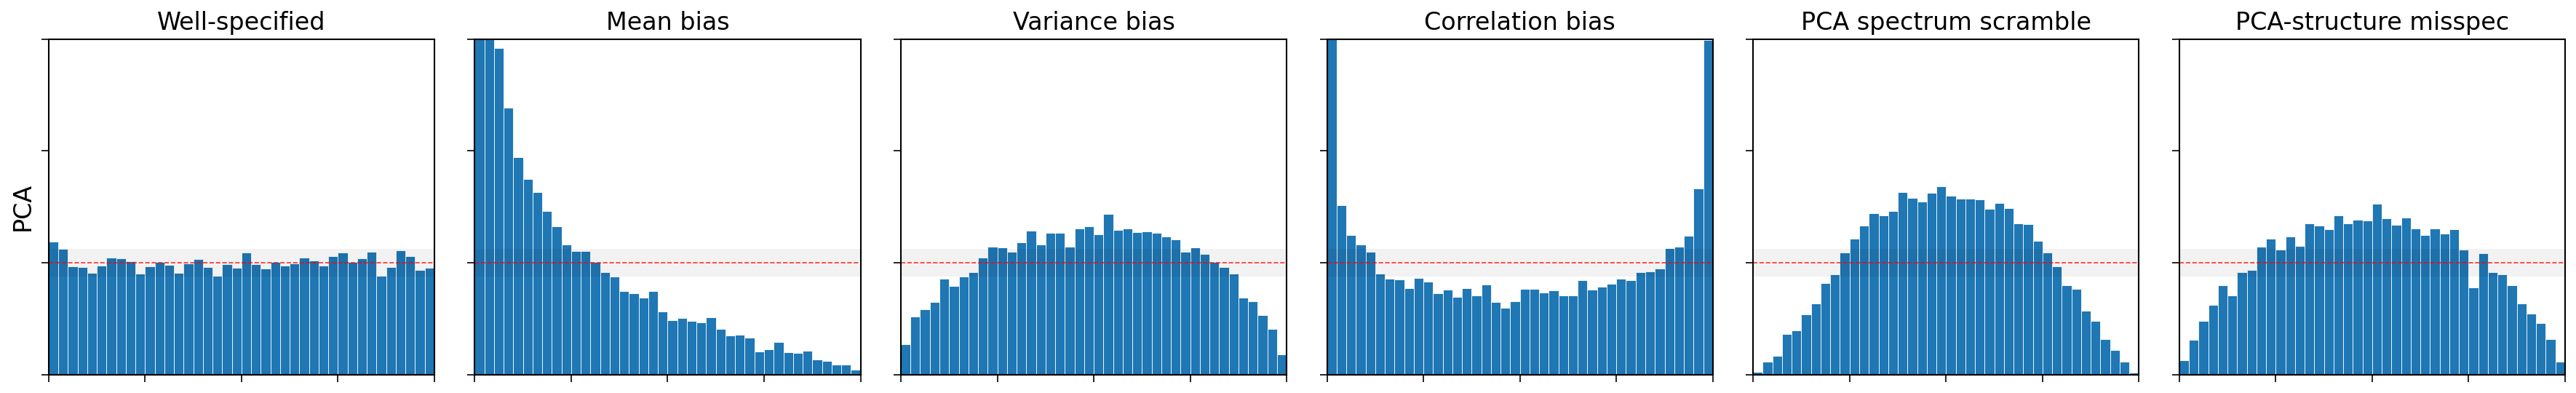

In [165]:
n_samples = 1000

preranks_main = ["pca"]

fig, axs = plt.subplots(len(preranks_main), len(cases), figsize=(4*len(cases), 4*len(preranks_main)), sharex=True)

for j, (case_name, mu_pred, cov_pred) in enumerate(cases):
    for i, pr in enumerate(preranks_main):
        pits = compute_pits_for_case(mu_pred, cov_pred, N, y, n_samples, pr)
        pits_1d = pits[0]
        ax = axs[i, j] if len(preranks_main) > 1 else axs[j]
        plot_pit_hist(ax, pits_1d, title=(case_name if i == 0 else ""), bins=40)

        ax.tick_params(
                axis="both",
                which="both",
                labelbottom=False,
                labelleft=False,
                length=5,     # size of the little bars
                width=0.8
            )

        if j == 0:
            ax.set_ylabel(preranks_map[pr], fontsize=16)

plt.tight_layout()
plt.savefig("preranks_multivariate_gaussian_just_pca.pdf", bbox_inches="tight")
plt.show()

In [91]:
def plot_prerank_group(pr_names, bins=50):
    n_rows = len(pr_names)
    n_cols = len(cases)

    fig, axs = plt.subplots(
        n_rows, n_cols,
        figsize=(3*n_cols, 2.5*n_rows),
        sharex=True,
        constrained_layout=True
    )

    for j, (case_name, mu_pred, cov_pred) in enumerate(cases):
        for i, pr in enumerate(pr_names):
            pits = compute_pits_for_case(mu_pred, cov_pred, N, y, n_samples, pr)  # (K,N) or (1,N)
            pits_1d = pits[0] if pits.ndim == 2 else pits

            ax = axs[i, j] if n_rows > 1 else axs[j]
            plot_pit_hist(ax, pits_1d, title=(case_name if i == 0 else ""), bins=bins)

            ax.tick_params(
                axis="both",
                which="both",
                labelbottom=False,
                labelleft=False,
                length=5,     # size of the little bars
                width=0.8
            )

            # Row labels only on first column
            if j == 0:
                ax.set_ylabel(preranks_map[pr], fontsize=16)

            # Clean small-multiples: only bottom row x labels, only left col y labels
            if i < n_rows - 1:
                ax.set_xticklabels([])
            if j > 0:
                ax.set_yticklabels([])

    # fig.supxlabel("PIT value")
    # fig.supylabel("Density")
    return fig

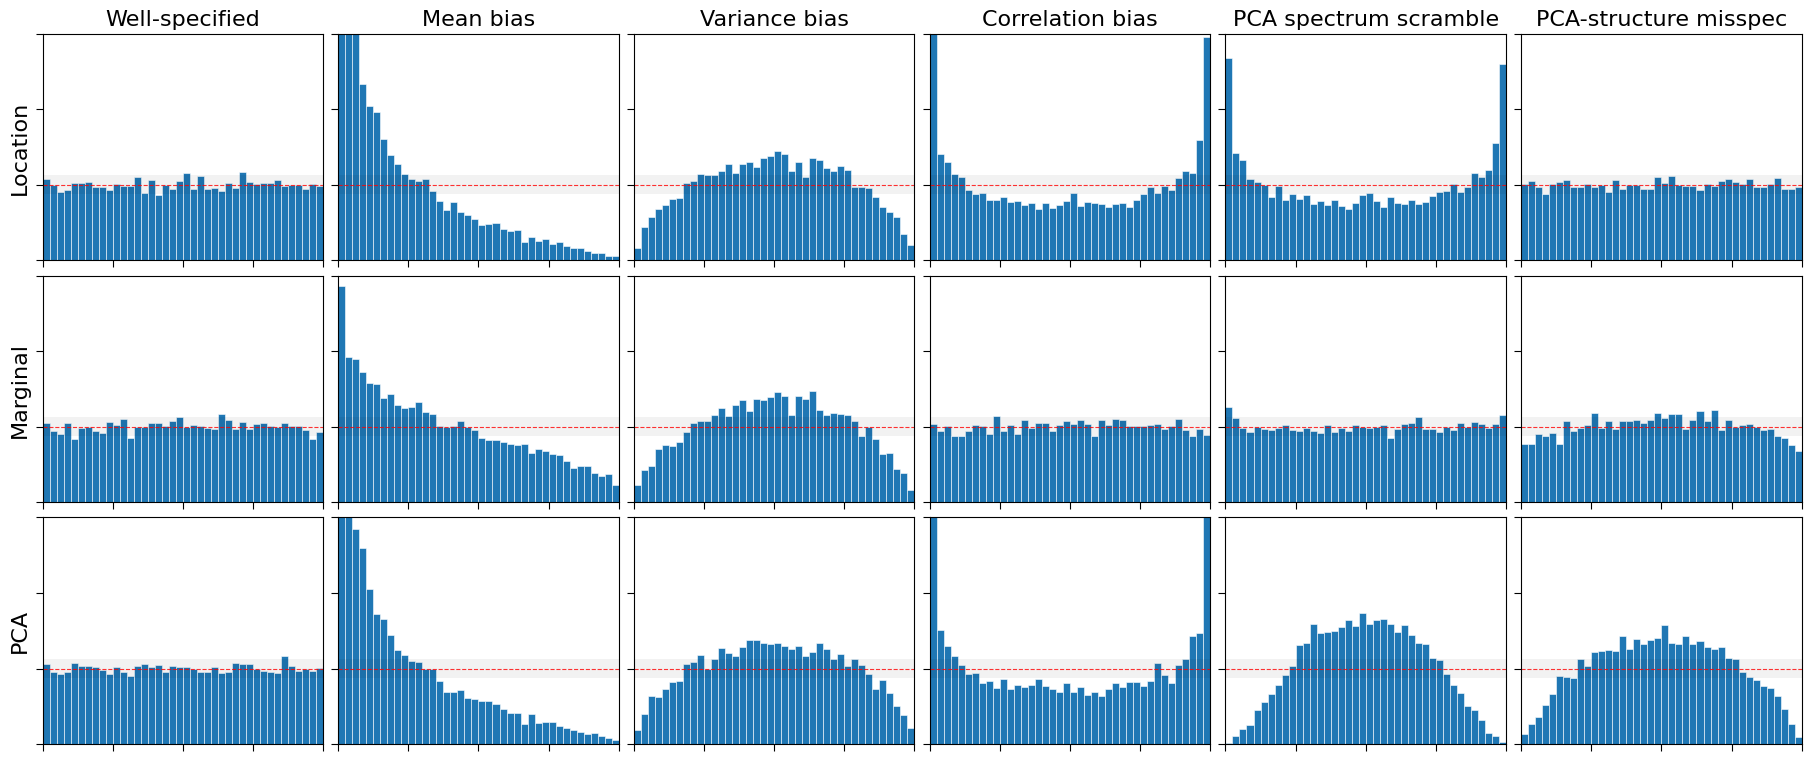

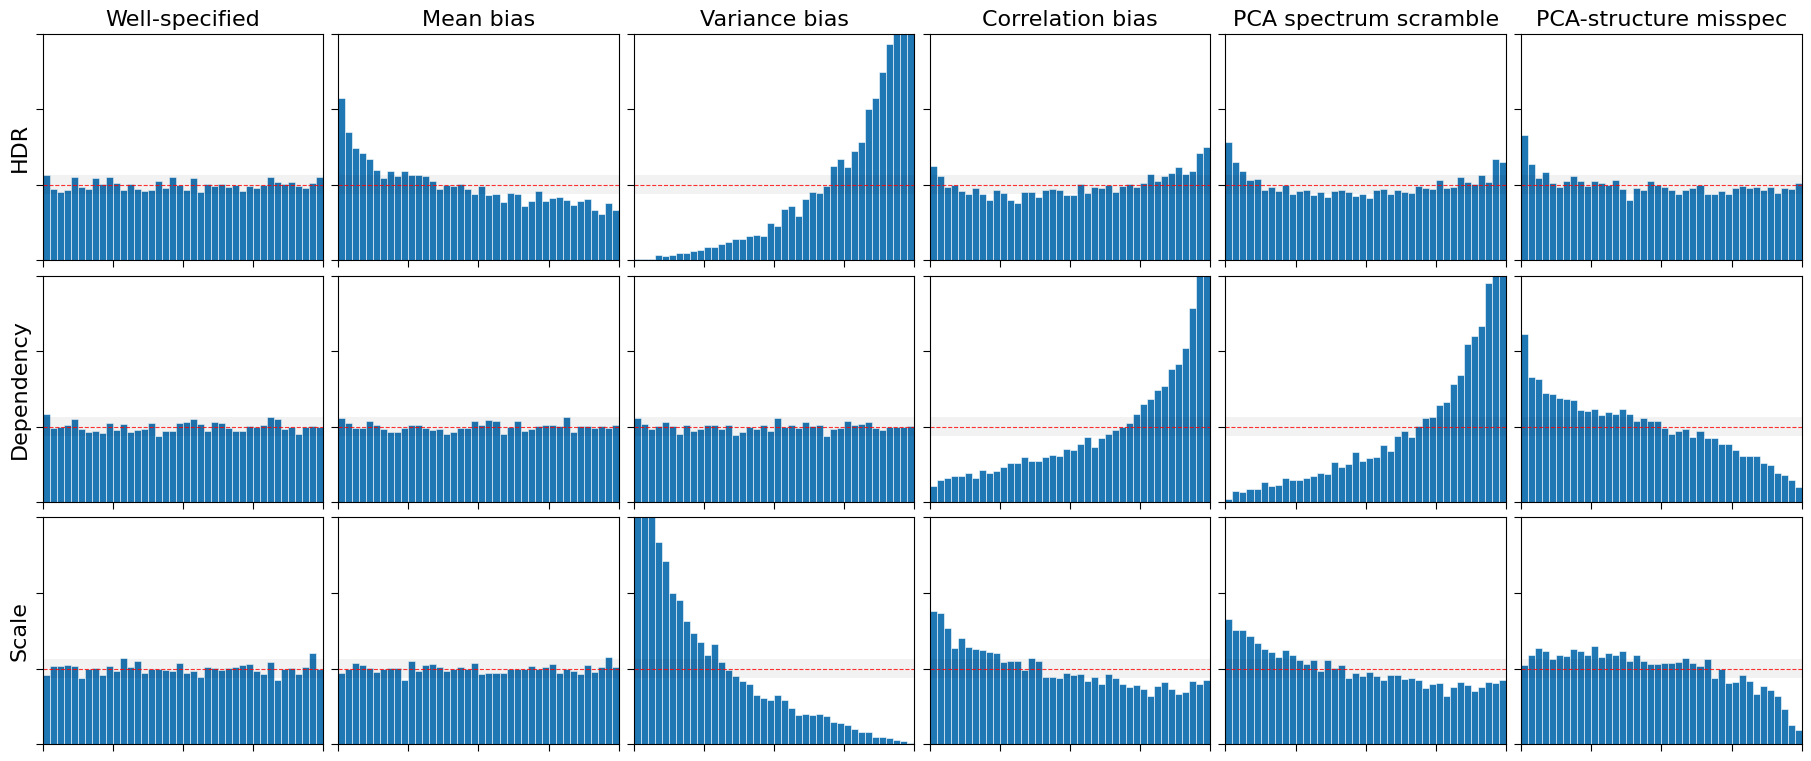

In [92]:
pr_group1 = ["mean", "marginal", "pca"]
pr_group2 = ["density", "dependency", "variance"]

fig1 = plot_prerank_group(
    pr_group1,
    bins=40
)

fig2 = plot_prerank_group(
    pr_group2,
    bins=40
)

fig1.savefig("preranks_rows_1_multivariate_gaussian.pdf", bbox_inches="tight")
fig2.savefig("preranks_rows_2_multivariate_gaussian.pdf", bbox_inches="tight")
plt.show()

# Simulation 2

In [64]:
p, q = 5, 5
d = p * q
N = 10_000
M = 20

coords = grid_points(p, q, device=device)

# Truth: isotropic
cov_true = exp_cov_euclid(coords, sigma2=1.0, tau=1.0)
mu_true = torch.zeros(d, device=device)
dist_true = torch.distributions.MultivariateNormal(mu_true, covariance_matrix=cov_true)

cov_pc_aniso_flip = cov_pc_anisotropy_flip(cov_true, axis_ratio=5.0)
cov_pc_strong = cov_pc_strong_misspec(cov_true, k=1)  # combines swap + rotation + anisotropy
cov_pca_not_mean = make_pca_not_mean_misspec(cov_true, c=5.0, k=1)

cases = [
    ("Well-specified",      torch.zeros(d), exp_cov_euclid(coords, 1.0, 1.0)),
    ("Mean bias",           0.5 * torch.ones(d, device=device), exp_cov_euclid(coords, 1.0, 1.0)), # (+0.5)
    # ("Mean bias (-0.5)",          -0.5 * torch.ones(d, device=device), exp_cov_euclid(coords, 1.0, 1.0)), # (-0.5)
    # ("Var under",           torch.zeros(d), exp_cov_euclid(coords, 0.55, 1.0)),
    ("Variance bias",            torch.zeros(d), exp_cov_euclid(coords, 1.75, 1.0)),
    ("Correlation bias",    torch.zeros(d), exp_cov_euclid(coords, 1.0, 0.3)),
    # ("Corr over",     torch.zeros(d), exp_cov_euclid(coords, 1.0, 2.5)),
    ("Isotropy misspec",torch.zeros(d), exp_cov_euclid_aniso(coords, 1.0, 1.0, y_scale=5)),
    ("PC anisotropy flip", torch.zeros(d), cov_pc_aniso_flip),
    ("PCA-structure misspec", torch.zeros(d), cov_pca_not_mean),

]
# Draw truth once
y = dist_true.sample((N,))  # (N, d)

sim_grf = {}
for name, mu_pred, cov_pred in cases:
    mu_pred = mu_pred.to(device)
    cov_pred = cov_pred.to(device)
    dist_pred = torch.distributions.MultivariateNormal(mu_pred, covariance_matrix=cov_pred)
    x = dist_pred.sample((N, M))  # (N, M, d)
    sim_grf[name] = {"y": y, "x": x, "mu_pred": mu_pred, "Sigma_pred": cov_pred}

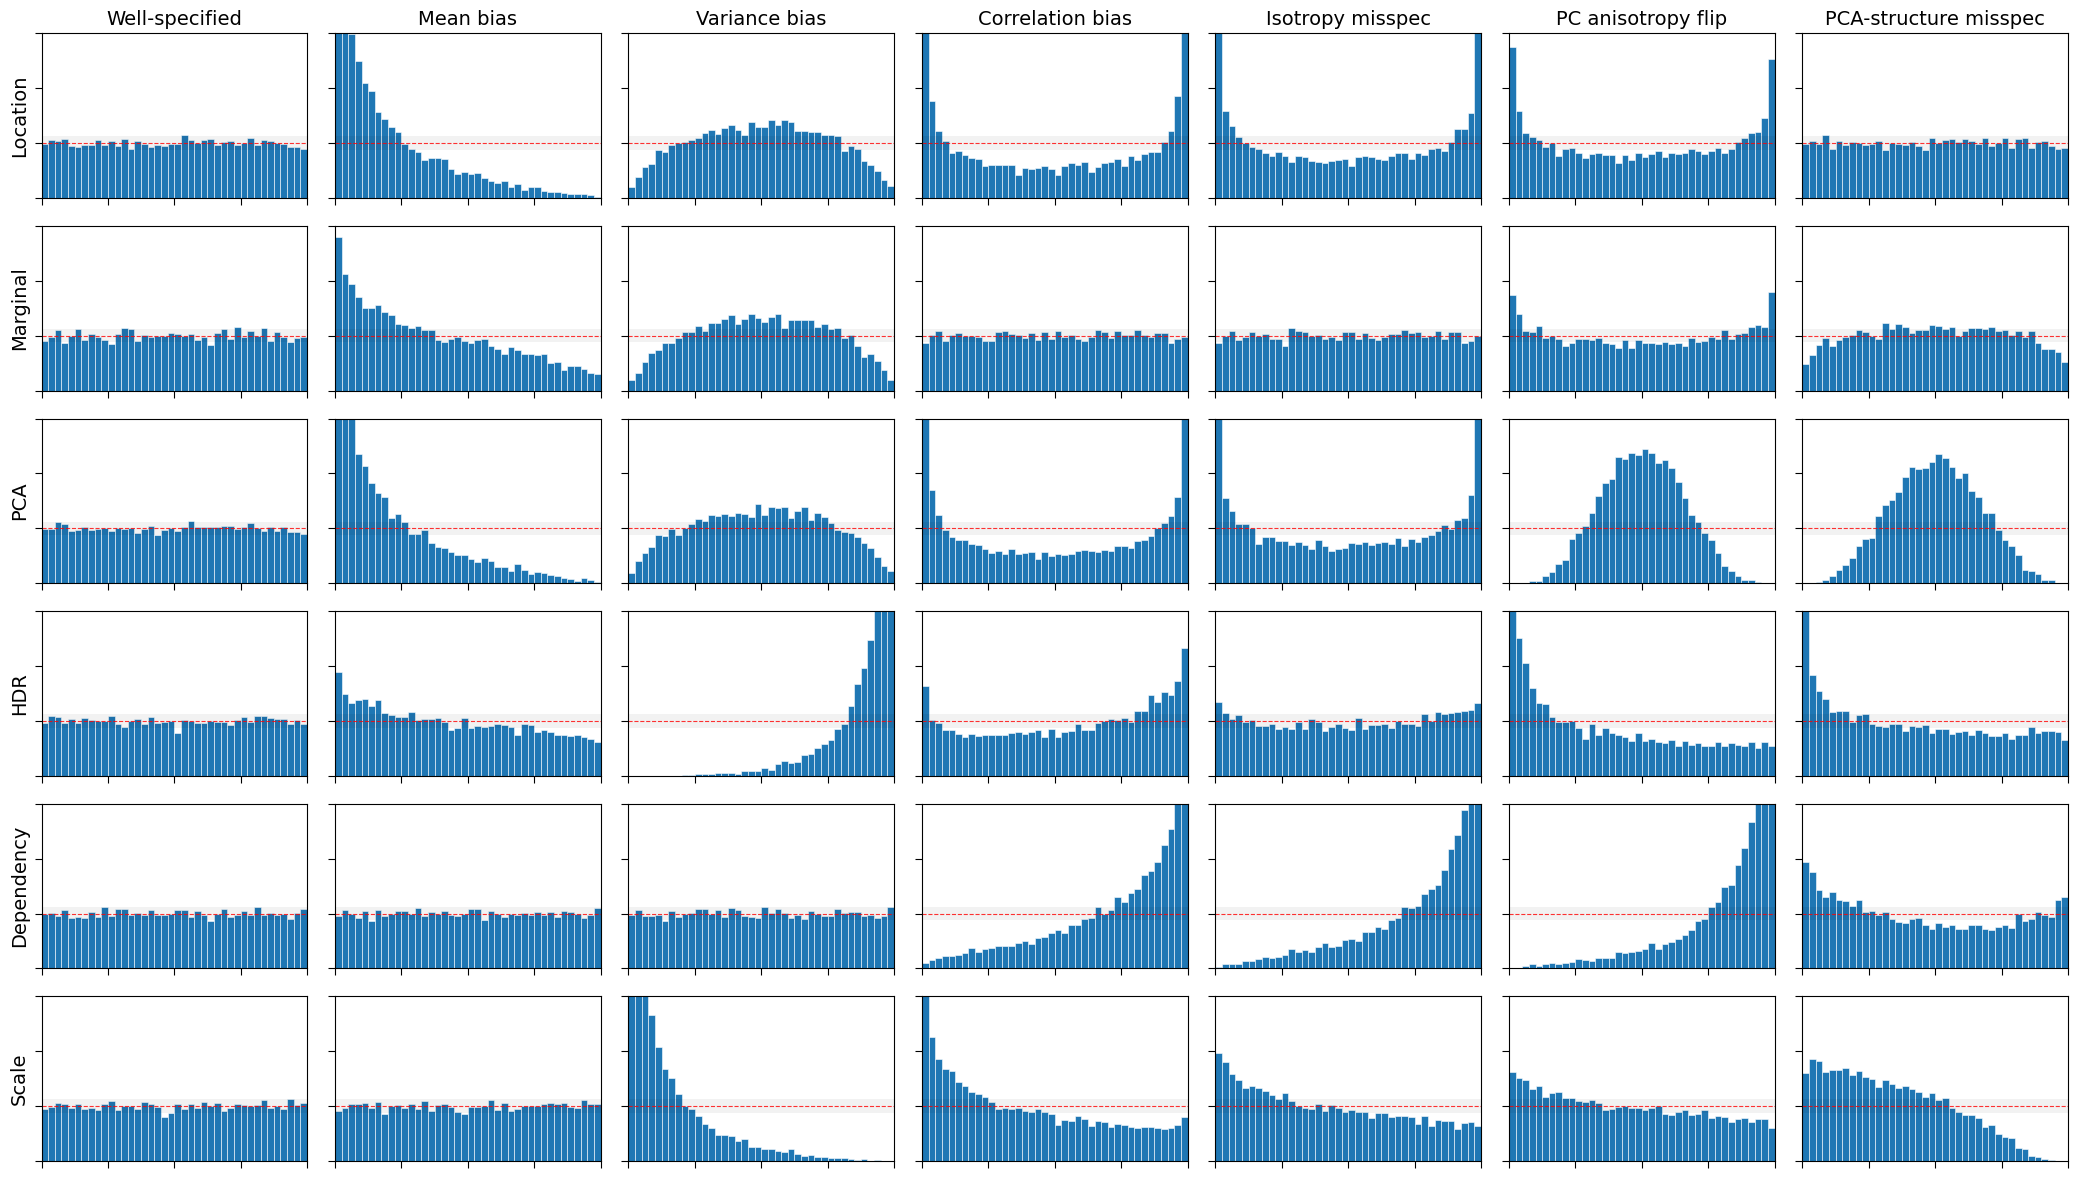

In [ ]:
n_samples = 1000

preranks_main = ["mean", "marginal", "pca", "density", "dependency", "variance"]

fig, axs = plt.subplots(len(preranks_main), len(cases), figsize=(3*len(cases), 2*len(preranks_main)), sharex=True)

for j, (case_name, mu_pred, cov_pred) in enumerate(cases):
    for i, pr in enumerate(preranks_main):
        pits = compute_pits_for_case(mu_pred, cov_pred, N, y, n_samples, pr)  # (K,N)
        # If K>1 (e.g., pca has 2 components), just plot the first component for main figure,
        # or average them if you want (see note below).
        pits_1d = pits[0]
        ax = axs[i, j] if len(preranks_main) > 1 else axs[j]
        plot_pit_hist(ax, pits_1d, title=(case_name if i == 0 else ""))
        ax.tick_params(
                axis="both",
                which="both",
                labelbottom=False,
                labelleft=False,
                length=5,     # size of the little bars
                width=0.8
            )
        if j == 0:
            ax.set_ylabel(preranks_map[pr], fontsize=14)

plt.tight_layout()
plt.savefig("preranks_gaussian_fields_ALL_CASES.pdf", bbox_inches="tight")
plt.show()

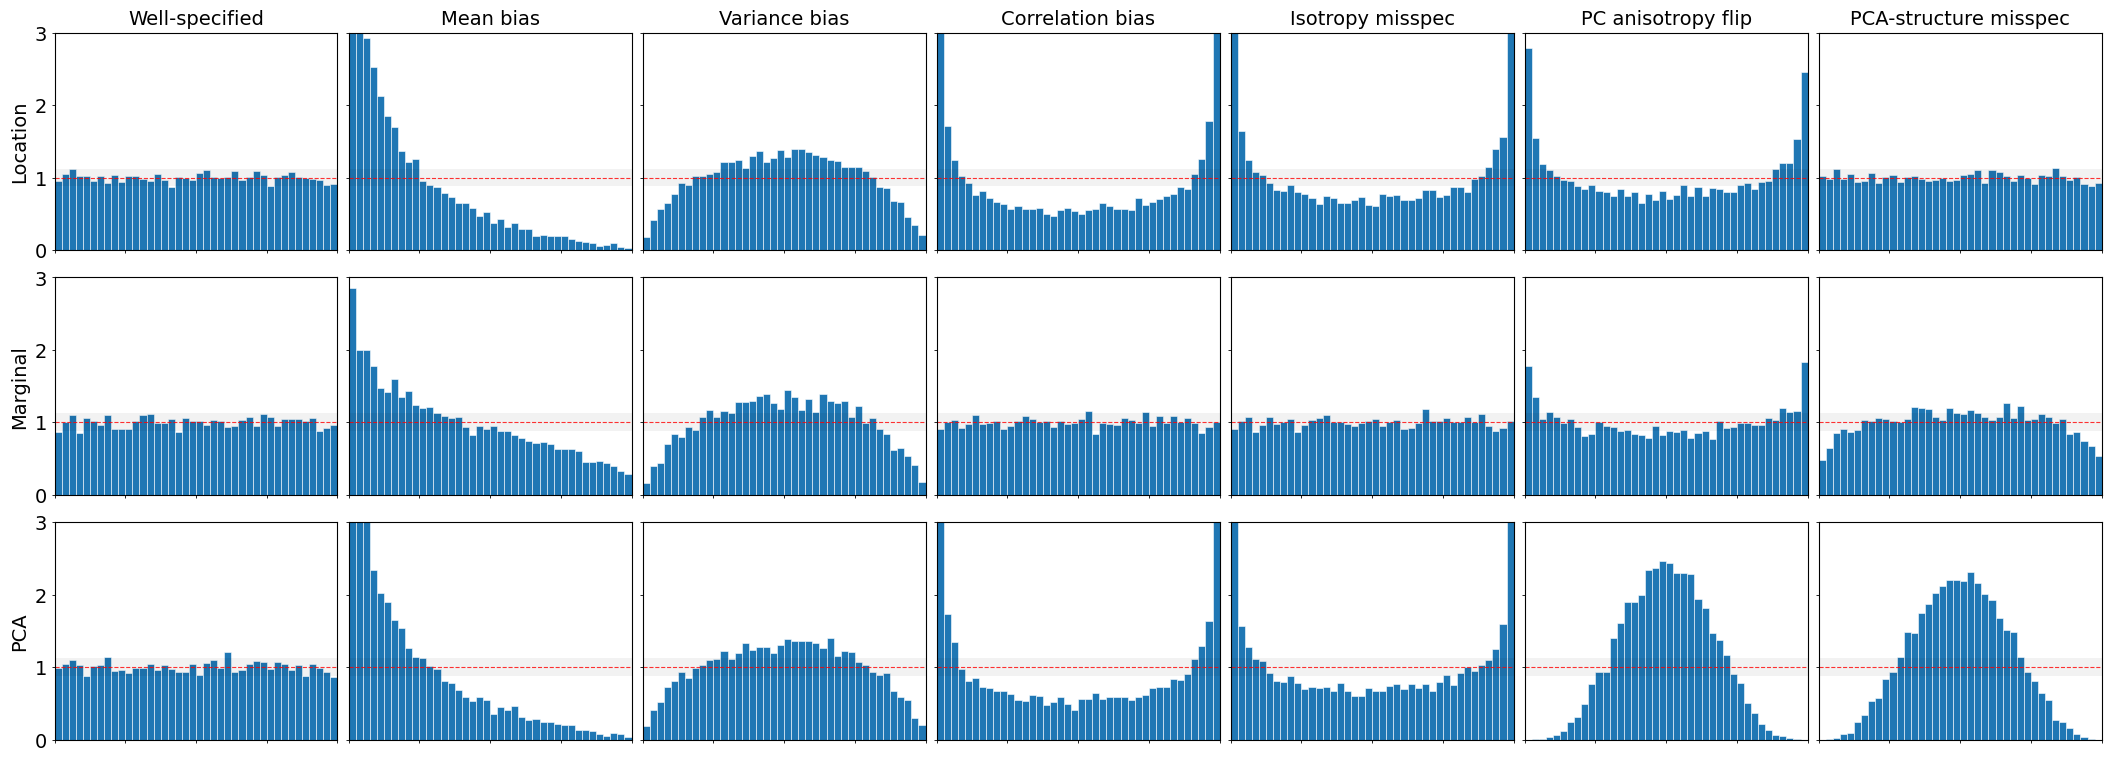

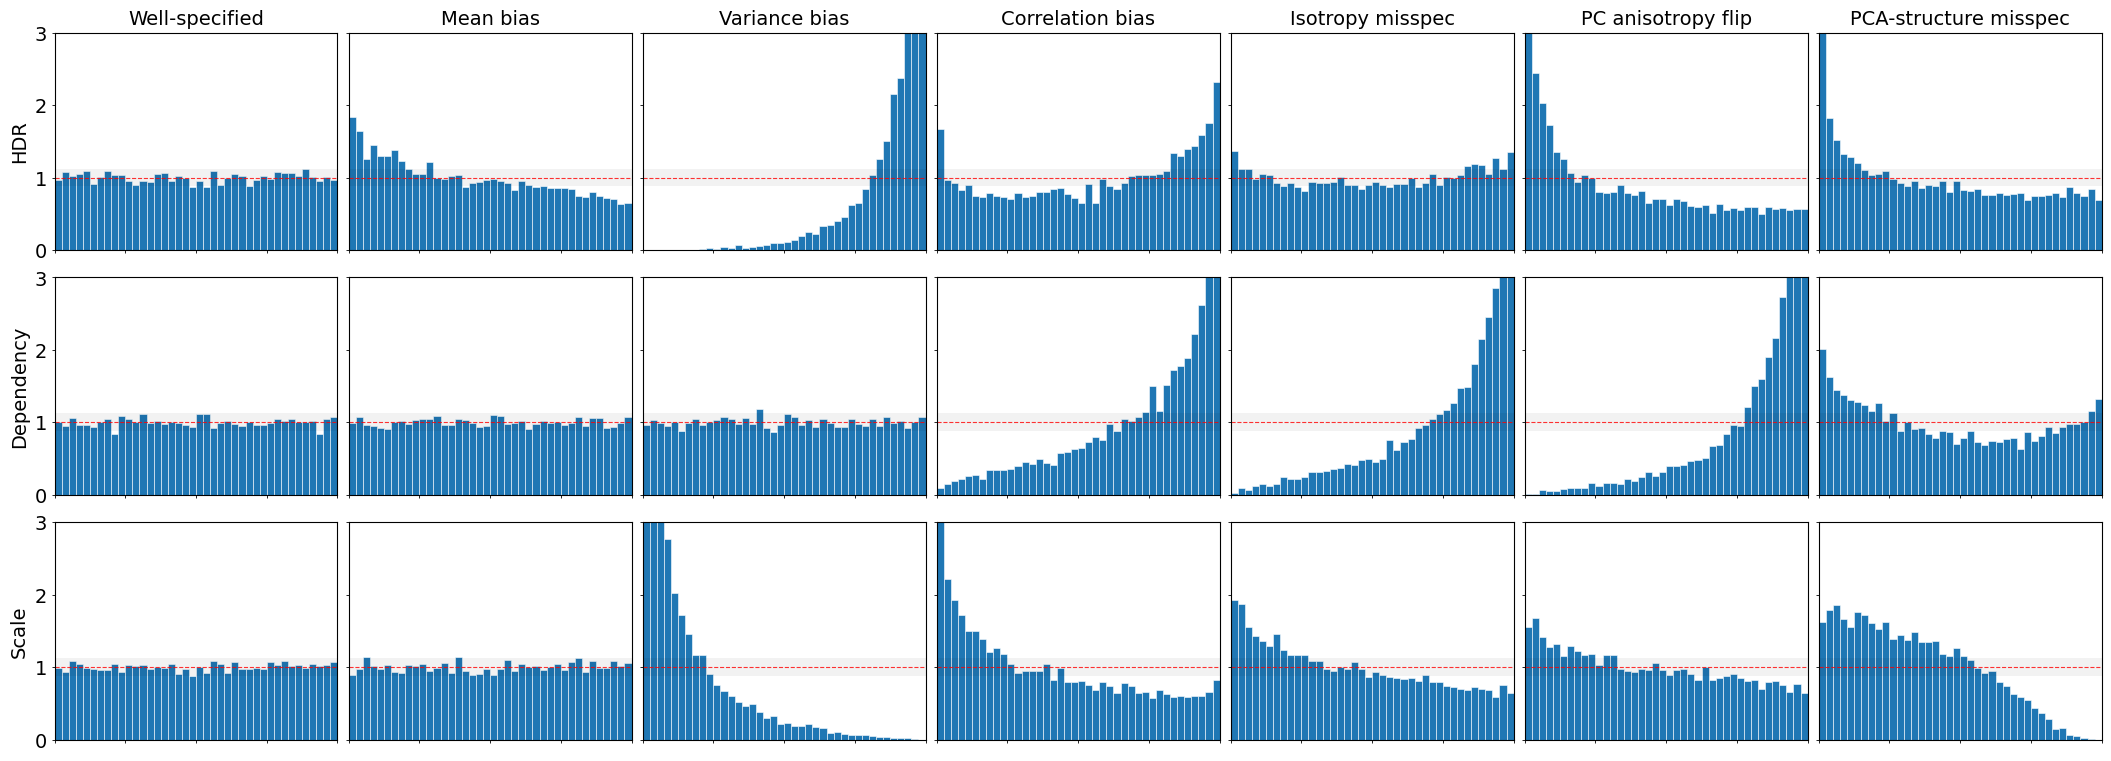

In [84]:
pr_group1 = ["mean", "marginal", "pca"]
pr_group2 = ["density", "dependency", "variance"]

fig1 = plot_prerank_group(
    pr_group1,
    bins=40
)

fig2 = plot_prerank_group(
    pr_group2,
    bins=40
)

fig1.savefig("preranks_rows_1_gaussian_fields.pdf", bbox_inches="tight")
fig2.savefig("preranks_rows_2_gaussian_fields.pdf", bbox_inches="tight")
plt.show()

In [99]:
def pits_1d_for_pr(mu_pred, cov_pred, pr, N, y, n_samples, agg="mean"):
    """
    Returns a 1D numpy array of length N for this prerank.
    If compute_pits_for_case returns KxN (e.g. PCA with K>1), we aggregate over K.
    """
    pits = compute_pits_for_case(mu_pred, cov_pred, N, y, n_samples, pr)  # (K,N) or (1,N)

    if pits.ndim == 2 and pits.shape[0] > 1:
        if agg == "mean":
            pits_1d = pits.mean(dim=0)          # length N
        elif agg == "maxdev":
            pits_1d = (pits - 0.5).abs().max(dim=0).values  # length N, emphasizes worst component
        else:
            raise ValueError("Unknown agg")
    else:

        pits_1d = pits[0] if pits.ndim == 2 else pits

    return pits_1d.detach().cpu().numpy()

def corr_table_for_case(case_name, mu_pred, cov_pred, N, y, n_samples, preranks, agg="mean"):
    cols = {}
    for pr in preranks:
        cols[pr] = pits_1d_for_pr(mu_pred, cov_pred, pr, N, y, n_samples, agg=agg)

    df = pd.DataFrame(cols)  # shape (N, P)
    corr = df.corr(method="spearman")  # Spearman = correlation between ranks
    corr.index.name = case_name
    return corr

# --- compute per-case correlation matrices ---
corr_by_case = {}
for case_name, mu_pred, cov_pred in cases:
    corr_by_case[case_name] = corr_table_for_case(
        case_name, mu_pred, cov_pred, N, y, n_samples,
        preranks=preranks_main,
        agg="mean"  # recommended
    )

# Example: print one table
print(corr_by_case["Well-specified"].round(2))

# Optional: export all cases to LaTeX (one file per case)
for name, corr in corr_by_case.items():
    safe = name.lower().replace(" ", "_").replace("-", "_")
    with open(f"rankcorr_{safe}.tex", "w") as f:
        f.write(corr.round(2).to_latex())

                mean  marginal   pca  density  dependency  variance
Well-specified                                                     
mean            1.00      0.99  0.69    -0.00        0.00      0.01
marginal        0.99      1.00  0.69    -0.00        0.00      0.01
pca             0.69      0.69  1.00    -0.00       -0.00      0.00
density        -0.00     -0.00 -0.00     1.00       -0.02     -0.83
dependency      0.00      0.00 -0.00    -0.02        1.00      0.31
variance        0.01      0.01  0.00    -0.83        0.31      1.00


In [100]:
print(corr_by_case["Isotropy misspec"].round(2))

                  mean  marginal   pca  density  dependency  variance
Isotropy misspec                                                     
mean              1.00      0.99  0.74    -0.00        0.00      0.01
marginal          0.99      1.00  0.74    -0.00        0.00      0.01
pca               0.74      0.74  1.00    -0.00       -0.00     -0.00
density          -0.00     -0.00 -0.00     1.00       -0.27     -0.84
dependency        0.00      0.00 -0.00    -0.27        1.00      0.31
variance          0.01      0.01 -0.00    -0.84        0.31      1.00


In [96]:
corr_stack = np.stack([c.values for c in corr_by_case.values()], axis=0)  # (n_cases, P, P)
corr_mean = pd.DataFrame(
    corr_stack.mean(axis=0),
    index=preranks_main,
    columns=preranks_main
)
print(corr_mean.round(2))

            mean  marginal   pca  density  dependency  variance
mean        1.00      0.99  0.77    -0.00        0.00      0.01
marginal    0.99      1.00  0.77    -0.00        0.00      0.01
pca         0.77      0.77  1.00     0.00        0.00      0.00
density    -0.00     -0.00  0.00     1.00       -0.13     -0.81
dependency  0.00      0.00  0.00    -0.13        1.00      0.31
variance    0.01      0.01  0.00    -0.81        0.31      1.00


# Trained model with Pre-rank - Metrics  

In [1]:
def summarize_prerank_csv(path):
    df = pd.read_csv(path)

    # numeric metrics except seed
    metric_cols = df.select_dtypes("number").columns.drop("seed")

    # average across seeds, per dataset
    out = (
        df.groupby("data_name")[metric_cols]
          .mean()
          .reset_index()
    )
    # out = out.drop(columns=["epochs_trained", "best_epoch"])

    return out

In [2]:
def boxplot_metric(df_total, metric):
    preranks = df_total["prerank"].unique()
    data = [
        df_total[df_total["prerank"] == pr][metric].values
        for pr in preranks
    ]

    plt.figure()
    plt.boxplot(data, labels=preranks)
    plt.xlabel("Prerank")
    plt.ylabel(metric.upper())
    plt.yscale("log")
    plt.title(f"{metric.upper()} across datasets")
    plt.show()

In [3]:
def make_metric_table(df_total, metric):
    """
    Rows: datasets
    Columns: preranks
    Values: metric
    """
    return (
        df_total
        .pivot(index="data_name", columns="prerank", values=metric)
        .sort_index()
    )
def highlight_best(row):
    best = row.max()
    return [
        "background-color: #ff0000" if v == best else ""
        for v in row
    ]

def highlight_best2(row):
    best = row.min()
    return [
        "background-color: #d8f5d3" if v == best else ""
        for v in row
    ]

def styled_metric_table(df_total, metric):
    table = make_metric_table(df_total, metric)
    return table.style.apply(highlight_best, axis=1)


In [6]:
preranks = ["mean", "marginal", "pca", "density", "dependency", "variance", "cdf"]
df_total = pd.DataFrame()
df_total["prerank"] = []
for pr in preranks:
    print(f"Processing prerank: {pr}")
    df = pd.read_csv(f"csv-files/FINAL-results/metrics_{pr}_lambda=10.csv")
    df["prerank"] = [pr]*len(df)
    df_total = pd.concat([df_total, df])

Processing prerank: mean
Processing prerank: marginal
Processing prerank: pca
Processing prerank: density
Processing prerank: dependency
Processing prerank: variance
Processing prerank: cdf


In [10]:
df_total.data_name.unique()

array(['wage', 'households', 'air', 'births1', 'births2', 'scm20d',
       'scm1d', 'wq', 'scpf', 'meps_21', 'meps_19', 'meps_20', 'house',
       'bio', 'blog_data', 'calcofi'], dtype=object)

In [7]:
df_total

,prerank,data_name,seed,train_prerank,train_time_seconds,epochs_trained,best_epoch,nll,energy,mse,pce_marginal,pce_mean,pce_variance,pce_dependency,pce_pca,pce_density,pce_cdf
0,mean,wage,0.0,mean,212.001322,177.0,161.0,2.296749,0.706585,0.663564,0.040537,0.028933,0.056305,0.059369,0.034525,0.042924,0.029500
1,mean,wage,42.0,mean,26.402564,21.0,5.0,2.918857,0.908859,1.019483,0.137027,0.096076,0.198339,0.197387,0.105068,0.333665,0.144817
2,mean,wage,866.0,mean,96.379435,75.0,59.0,0.436684,0.743512,0.746923,0.101525,0.024064,0.113968,0.116329,0.065868,0.412870,0.078055
3,mean,wage,12.0,mean,116.844272,92.0,76.0,0.773972,0.730518,0.720171,0.089024,0.028895,0.121459,0.120835,0.054835,0.371650,0.067226
4,mean,wage,4.0,mean,29.719258,23.0,7.0,2.848583,0.895026,0.995768,0.127629,0.092105,0.174366,0.175039,0.099395,0.311310,0.140071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,cdf,house,42.0,cdf,3531.063139,297.0,281.0,1.015021,0.558080,0.496507,0.052681,0.041004,0.079561,0.080315,0.065662,0.186208,0.022888
62,cdf,house,866.0,cdf,4702.699265,391.0,375.0,0.695867,0.552434,0.530718,0.044780,0.041541,0.086221,0.087076,0.064767,0.214481,0.020795
63,cdf,house,12.0,cdf,7985.801850,418.0,402.0,0.625930,0.529827,0.470542,0.054109,0.038869,0.077158,0.078423,0.057612,0.213743,0.024247
64,cdf,house,4.0,cdf,8280.746968,431.0,415.0,0.792015,0.553047,0.519233,0.033285,0.042862,0.083740,0.085521,0.055248,0.166298,0.021068


In [125]:
preranks = ["mean", "marginal", "pca", "density", "dependency", "variance", "cdf"]
df_total = pd.DataFrame()
df_total["prerank"] = []
for pr in preranks:
    print(f"Processing prerank: {pr}")
    df = summarize_prerank_csv(f"csv-files/NEW-metrics-from-model-trained-on-train_prerank={pr}.csv")
    df["prerank"] = [pr]*len(df)
    df_total = pd.concat([df_total, df])

Processing prerank: mean
Processing prerank: marginal
Processing prerank: pca
Processing prerank: density
Processing prerank: dependency
Processing prerank: variance
Processing prerank: cdf


In [130]:
df_m = summarize_prerank_csv(f"csv-files/metrics-from-model-trained-on-train_prerank=Marginal+Mean+Variance+Dependency+Density+CDF.csv")
df_m["prerank"] = "Marginal+ALL"
df_m

,data_name,train_prerank,train_time_seconds,epochs_trained,best_epoch,nll,energy,mse,pce_marginal,pce_mean,pce_variance,pce_dependency,pce_pca,pce_density,pce_cdf,prerank
0,air,NaN,1442.723080,128.4,112.4,5.569014,1.398915,0.917458,0.090567,0.084894,0.190579,0.050236,0.070902,0.073626,0.142574,Marginal+ALL
1,ansur2,NaN,279.921028,118.2,102.2,1.777335,0.536226,0.375091,0.067243,0.071111,0.094485,0.093595,0.066373,0.160222,0.078156,Marginal+ALL
2,bio,NaN,7613.150919,186.6,170.6,-0.644779,0.247802,0.401207,0.038496,0.020695,0.030297,0.035674,0.031205,0.031619,0.041187,Marginal+ALL
3,births1,NaN,1617.416502,143.6,127.6,1.100003,0.709011,0.844697,0.069934,0.070700,0.093303,0.094061,0.071171,0.202081,0.062592,Marginal+ALL
4,births2,NaN,1860.503892,168.8,152.8,-2.045305,0.892491,0.850092,0.174370,0.041074,0.058381,0.071146,0.107470,0.396461,0.105229,Marginal+ALL
5,blog_data,NaN,3396.012446,76.4,60.4,-0.574995,0.637979,0.819452,0.076707,0.060578,0.115023,0.116063,0.057104,0.202288,0.037442,Marginal+ALL
6,calcofi,NaN,63844.690155,89.8,74.6,0.580830,0.420447,0.333240,0.038047,0.028202,0.030933,0.032891,0.036549,0.028178,0.046801,Marginal+ALL
7,house,NaN,2489.598607,156.2,140.2,10.829436,0.564499,0.535693,0.093344,0.112838,0.087046,0.090757,0.101466,0.118935,0.090470,Marginal+ALL
8,households,NaN,869.221792,121.6,105.6,3.187130,0.925472,0.625692,0.088915,0.088542,0.122601,0.019624,0.065983,0.087620,0.137426,Marginal+ALL
9,meps_19,NaN,1084.481315,92.6,76.6,-1.999812,0.372656,0.601331,0.059845,0.052975,0.055088,0.040220,0.041907,0.216796,0.058318,Marginal+ALL


In [129]:
df = summarize_prerank_csv(f"csv-files/metrics-from-model-trained-on-train_prerank=PCA+Mean+Variance+Dependency+Density+CDF.csv")
df["prerank"] = "PCA+ALL"
df

,data_name,train_prerank,train_time_seconds,epochs_trained,best_epoch,nll,energy,mse,pce_marginal,pce_mean,pce_variance,pce_dependency,pce_pca,pce_density,pce_cdf,prerank
0,air,NaN,1545.398392,137.6,121.6,5.616107,1.400688,0.917023,0.093434,0.087699,0.189703,0.048215,0.071406,0.081146,0.143714,PCA+ALL
1,ansur2,NaN,259.437830,126.2,110.2,1.764311,0.531948,0.371291,0.063820,0.066205,0.091492,0.092448,0.061962,0.151454,0.070222,PCA+ALL
2,bio,NaN,12396.717963,305.0,289.0,-0.726106,0.242742,0.396796,0.041174,0.021919,0.033188,0.039561,0.032654,0.038221,0.040909,PCA+ALL
3,births1,NaN,1460.366380,128.0,112.0,1.248134,0.711699,0.846632,0.069648,0.069612,0.090456,0.091524,0.069966,0.183780,0.060549,PCA+ALL
4,births2,NaN,2102.880577,187.6,171.6,-3.809591,0.882445,0.835599,0.173945,0.038437,0.057314,0.065085,0.105638,0.385608,0.113778,PCA+ALL
5,blog_data,NaN,4396.381804,96.0,80.0,-0.618942,0.628650,0.795662,0.079395,0.057508,0.107014,0.107635,0.053662,0.199209,0.044633,PCA+ALL
6,calcofi,NaN,72721.221911,108.0,93.0,0.580018,0.420267,0.332828,0.040849,0.032737,0.030473,0.032321,0.036563,0.031474,0.050274,PCA+ALL
7,house,NaN,2831.161020,177.6,161.6,13.048640,0.544306,0.503950,0.101320,0.119496,0.093124,0.097780,0.109451,0.117358,0.099628,PCA+ALL
8,households,NaN,848.449051,119.2,103.2,3.161811,0.923041,0.625340,0.093160,0.092636,0.117420,0.021524,0.065274,0.089893,0.145510,PCA+ALL
9,meps_19,NaN,986.499701,81.0,65.0,-1.924698,0.381411,0.621588,0.063765,0.043622,0.054745,0.037590,0.036532,0.225691,0.049788,PCA+ALL


In [131]:
df_m = df_m.drop(columns=['epochs_trained', 'best_epoch', 'train_prerank'])
df_m

,data_name,train_time_seconds,nll,energy,mse,pce_marginal,pce_mean,pce_variance,pce_dependency,pce_pca,pce_density,pce_cdf,prerank
0,air,1442.723080,5.569014,1.398915,0.917458,0.090567,0.084894,0.190579,0.050236,0.070902,0.073626,0.142574,Marginal+ALL
1,ansur2,279.921028,1.777335,0.536226,0.375091,0.067243,0.071111,0.094485,0.093595,0.066373,0.160222,0.078156,Marginal+ALL
2,bio,7613.150919,-0.644779,0.247802,0.401207,0.038496,0.020695,0.030297,0.035674,0.031205,0.031619,0.041187,Marginal+ALL
3,births1,1617.416502,1.100003,0.709011,0.844697,0.069934,0.070700,0.093303,0.094061,0.071171,0.202081,0.062592,Marginal+ALL
4,births2,1860.503892,-2.045305,0.892491,0.850092,0.174370,0.041074,0.058381,0.071146,0.107470,0.396461,0.105229,Marginal+ALL
5,blog_data,3396.012446,-0.574995,0.637979,0.819452,0.076707,0.060578,0.115023,0.116063,0.057104,0.202288,0.037442,Marginal+ALL
6,calcofi,63844.690155,0.580830,0.420447,0.333240,0.038047,0.028202,0.030933,0.032891,0.036549,0.028178,0.046801,Marginal+ALL
7,house,2489.598607,10.829436,0.564499,0.535693,0.093344,0.112838,0.087046,0.090757,0.101466,0.118935,0.090470,Marginal+ALL
8,households,869.221792,3.187130,0.925472,0.625692,0.088915,0.088542,0.122601,0.019624,0.065983,0.087620,0.137426,Marginal+ALL
9,meps_19,1084.481315,-1.999812,0.372656,0.601331,0.059845,0.052975,0.055088,0.040220,0.041907,0.216796,0.058318,Marginal+ALL


In [132]:
df = df.drop(columns=['epochs_trained', 'best_epoch', 'train_prerank'])
df

,data_name,train_time_seconds,nll,energy,mse,pce_marginal,pce_mean,pce_variance,pce_dependency,pce_pca,pce_density,pce_cdf,prerank
0,air,1545.398392,5.616107,1.400688,0.917023,0.093434,0.087699,0.189703,0.048215,0.071406,0.081146,0.143714,PCA+ALL
1,ansur2,259.437830,1.764311,0.531948,0.371291,0.063820,0.066205,0.091492,0.092448,0.061962,0.151454,0.070222,PCA+ALL
2,bio,12396.717963,-0.726106,0.242742,0.396796,0.041174,0.021919,0.033188,0.039561,0.032654,0.038221,0.040909,PCA+ALL
3,births1,1460.366380,1.248134,0.711699,0.846632,0.069648,0.069612,0.090456,0.091524,0.069966,0.183780,0.060549,PCA+ALL
4,births2,2102.880577,-3.809591,0.882445,0.835599,0.173945,0.038437,0.057314,0.065085,0.105638,0.385608,0.113778,PCA+ALL
5,blog_data,4396.381804,-0.618942,0.628650,0.795662,0.079395,0.057508,0.107014,0.107635,0.053662,0.199209,0.044633,PCA+ALL
6,calcofi,72721.221911,0.580018,0.420267,0.332828,0.040849,0.032737,0.030473,0.032321,0.036563,0.031474,0.050274,PCA+ALL
7,house,2831.161020,13.048640,0.544306,0.503950,0.101320,0.119496,0.093124,0.097780,0.109451,0.117358,0.099628,PCA+ALL
8,households,848.449051,3.161811,0.923041,0.625340,0.093160,0.092636,0.117420,0.021524,0.065274,0.089893,0.145510,PCA+ALL
9,meps_19,986.499701,-1.924698,0.381411,0.621588,0.063765,0.043622,0.054745,0.037590,0.036532,0.225691,0.049788,PCA+ALL


In [ ]:
# df_total = df_total.drop(columns=['epochs_trained', 'best_epoch'])
# df_total = df_total.drop(columns=['seed'])

In [133]:
df_final = pd.concat([df_total, df, df_m])
df_final

,prerank,data_name,train_time_seconds,nll,energy,mse,pce_marginal,pce_mean,pce_variance,pce_dependency,pce_pca,pce_density,pce_cdf,pce
0,mean,air,165.714971,5.587274,1.404387,0.923503,0.097156,0.092217,0.209005,0.053445,0.075563,0.095812,0.150355,0.094
1,mean,ansur2,141.720124,1.763932,0.533458,0.373273,0.073807,0.079124,0.111811,0.111233,0.071467,0.176655,0.086611,0.100
2,mean,bio,888.339579,-0.687162,0.243784,0.396341,0.051894,0.031101,0.042745,0.049741,0.046169,0.037724,0.079730,0.049
3,mean,births1,171.332231,1.146576,0.708820,0.844384,0.078917,0.079404,0.108284,0.109954,0.077143,0.194613,0.067959,0.101
4,mean,births2,271.096140,-3.853731,0.883947,0.831192,0.177670,0.047170,0.070061,0.077781,0.112313,0.388600,0.112265,0.153
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13,Marginal+ALL,scm20d,781.767080,8.537912,2.330112,0.809472,0.068310,0.073955,0.129849,0.067816,0.036640,0.088445,0.072014,NaN
14,Marginal+ALL,scpf,486.689320,-4.534003,0.471066,1.369371,0.124621,0.100444,0.118761,0.071405,0.105579,0.342946,0.088738,NaN
15,Marginal+ALL,taxi,8322.792475,1.710379,0.695932,0.826782,0.072638,0.066672,0.078892,0.080621,0.078125,0.034346,0.083048,NaN
16,Marginal+ALL,wage,547.508619,0.432037,0.699675,0.705954,0.126955,0.078440,0.091786,0.093203,0.113208,0.412197,0.135325,NaN


In [114]:
df_without =  summarize_prerank_csv(f"csv-files/metrics-from-model-without-reg.csv")
df_without["prerank"] = "without"
df_total = pd.concat([df_total, df_without])

In [115]:
df_total

,prerank,data_name,train_time_seconds,nll,energy,mse,pce_marginal,pce_mean,pce_variance,pce_dependency,pce_pca,pce_density,pce_cdf
0,mean,air,165.714971,5.587274,1.404387,0.923503,0.097156,0.092217,0.209005,0.053445,0.075563,0.095812,0.150355
1,mean,ansur2,141.720124,1.763932,0.533458,0.373273,0.073807,0.079124,0.111811,0.111233,0.071467,0.176655,0.086611
2,mean,bio,888.339579,-0.687162,0.243784,0.396341,0.051894,0.031101,0.042745,0.049741,0.046169,0.037724,0.079730
3,mean,births1,171.332231,1.146576,0.708820,0.844384,0.078917,0.079404,0.108284,0.109954,0.077143,0.194613,0.067959
4,mean,births2,271.096140,-3.853731,0.883947,0.831192,0.177670,0.047170,0.070061,0.077781,0.112313,0.388600,0.112265
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11,without,scm1d,NaN,8.847594,2.056670,0.647925,0.053573,0.059117,0.098263,0.085634,0.041422,0.079706,0.062919
12,without,scm20d,NaN,8.056097,2.323931,0.804209,0.073451,0.079903,0.139870,0.071296,0.038750,0.085465,0.078230
13,without,scpf,NaN,-3.198202,0.504484,1.390059,0.184705,0.181519,0.119859,0.091188,0.135189,0.351022,0.181052
14,without,wage,NaN,0.461110,0.700426,0.710224,0.132236,0.085333,0.108759,0.111032,0.114262,0.415032,0.141996


In [8]:
df_matched = df_total[df_total['prerank'] != 'without'].copy()

df_matched['pce'] = df_matched.apply(lambda row: row[f"pce_{row['prerank']}"], axis=1)

final_cols = [
    'data_name',
    'seed',
    'prerank',
    'pce',
    'nll',
    'energy',
    'mse',
    'train_time_seconds',
    'epochs_trained',
    'best_epoch'
]


df_clean = df_matched[[col for col in final_cols if col in df_matched.columns]].copy()

df_clean = df_clean.reset_index(drop=True)

df_clean

,data_name,seed,prerank,pce,nll,energy,mse,train_time_seconds,epochs_trained,best_epoch
0,wage,0.0,mean,0.028933,2.296749,0.706585,0.663564,212.001322,177.0,161.0
1,wage,42.0,mean,0.096076,2.918857,0.908859,1.019483,26.402564,21.0,5.0
2,wage,866.0,mean,0.024064,0.436684,0.743512,0.746923,96.379435,75.0,59.0
3,wage,12.0,mean,0.028895,0.773972,0.730518,0.720171,116.844272,92.0,76.0
4,wage,4.0,mean,0.092105,2.848583,0.895026,0.995768,29.719258,23.0,7.0
...,...,...,...,...,...,...,...,...,...,...
583,house,42.0,cdf,0.022888,1.015021,0.558080,0.496507,3531.063139,297.0,281.0
584,house,866.0,cdf,0.020795,0.695867,0.552434,0.530718,4702.699265,391.0,375.0
585,house,12.0,cdf,0.024247,0.625930,0.529827,0.470542,7985.801850,418.0,402.0
586,house,4.0,cdf,0.021068,0.792015,0.553047,0.519233,8280.746968,431.0,415.0


In [9]:
df_clean.to_csv("metrics_after_reg_lambda=10_new.csv", index=False)

In [13]:
pce_mse_table = (
    df_total
    .pivot(index="data_name", columns="prerank", values="mse")
    .sort_index()
)

pce_mse_table.style.apply(highlight_best2, axis=1)

prerank,cdf,density,dependency,marginal,mean,pca,variance
data_name,,,,,,,
air,0.913309,0.918892,0.919843,0.918562,0.923503,0.916647,0.920505
ansur2,0.373931,nan,0.375264,0.373209,0.373273,0.374590,0.374174
bio,0.403503,0.405012,0.402478,0.399997,0.396341,0.393091,0.398092
births1,0.844221,0.848687,0.847837,0.848827,0.844384,0.851473,0.843306
births2,0.838279,0.840519,0.847011,0.840297,0.831192,0.836717,0.841752
blog_data,0.853136,0.814393,0.864261,0.810514,0.811344,0.821558,0.800262
calcofi,0.330947,0.331174,0.330962,0.330908,0.331001,0.330870,0.330933
house,0.533141,0.541011,0.537291,0.521861,0.522655,0.522791,0.528782
households,0.631071,0.623486,0.631947,0.628394,0.632470,0.629166,0.628863


In [14]:
pce_energy_table = (
    df_total
    .pivot(index="data_name", columns="prerank", values="energy")
    .sort_index()
)

pce_energy_table.style.apply(highlight_best2, axis=1)

prerank,cdf,density,dependency,marginal,mean,pca,variance
data_name,,,,,,,
air,1.397137,1.396861,1.402864,1.398349,1.404387,1.400026,1.401840
ansur2,0.535338,nan,0.534598,0.532659,0.533458,0.535683,0.534017
bio,0.248041,0.252050,0.247841,0.246026,0.243784,0.241322,0.244876
births1,0.707669,0.712464,0.708198,0.711681,0.708820,0.712200,0.709327
births2,0.893961,0.889327,0.898671,0.896204,0.883947,0.885578,0.894464
blog_data,0.635670,0.634132,0.636738,0.637221,0.634247,0.638028,0.631556
calcofi,0.419975,0.420107,0.420085,0.420062,0.420066,0.420035,0.420091
house,0.565004,0.568681,0.563571,0.558187,0.558451,0.558853,0.564091
households,0.927505,0.923606,0.928451,0.925802,0.929887,0.927142,0.927466


In [15]:
pce_nll_table = (
    df_total
    .pivot(index="data_name", columns="prerank", values="nll")
    .sort_index()
)

pce_nll_table.style.apply(highlight_best2, axis=1)

prerank,cdf,density,dependency,marginal,mean,pca,variance
data_name,,,,,,,
air,5.594623,5.621278,5.616154,5.591807,5.587274,5.573239,5.596642
ansur2,1.767253,nan,1.771177,1.771705,1.763932,1.773340,1.766305
bio,-0.544998,-0.368824,-0.625840,-0.660235,-0.687162,-0.732765,-0.664702
births1,1.254779,1.490198,1.147786,1.191378,1.146576,1.411556,1.237860
births2,-4.736531,-4.066595,-3.357687,-3.037960,-3.853731,-4.576969,-4.436870
blog_data,-0.560490,-0.637106,-0.601164,-0.579065,-0.551348,-0.435253,-0.602576
calcofi,0.566552,0.568785,0.570207,0.570834,0.570989,0.569972,0.572185
house,2.622952,1.963080,4.452247,5.388698,4.618206,6.997695,6.910625
households,3.211862,3.221953,3.193192,3.225438,3.256352,3.228312,3.169634


In [16]:
pce_mean_table = (
    df_total
    .pivot(index="data_name", columns="prerank", values="pce_mean")
    .sort_index()
)

pce_mean_table.style.apply(highlight_best2, axis=1)

prerank,cdf,density,dependency,marginal,mean,pca,variance
data_name,,,,,,,
air,0.091828,0.094688,0.095139,0.092175,0.092217,0.095268,0.094773
ansur2,0.082726,nan,0.073542,0.074129,0.079124,0.074119,0.072092
bio,0.030849,0.048548,0.068916,0.050920,0.031101,0.042223,0.055236
births1,0.080718,0.079383,0.081903,0.080217,0.079404,0.077502,0.081647
births2,0.045903,0.053374,0.051007,0.047484,0.047170,0.053095,0.049381
blog_data,0.065751,0.068857,0.065873,0.065967,0.069510,0.066314,0.067371
calcofi,0.073861,0.086739,0.083051,0.073530,0.066282,0.076055,0.078544
house,0.119581,0.118547,0.122545,0.119691,0.116268,0.118173,0.116021
households,0.092408,0.100914,0.102460,0.094221,0.092717,0.099447,0.104010


In [17]:
pce_pca_table = (
    df_total
    .pivot(index="data_name", columns="prerank", values="pce_pca")
    .sort_index()
)

pce_pca_table.style.apply(highlight_best2, axis=1)

prerank,cdf,density,dependency,marginal,mean,pca,variance
data_name,,,,,,,
air,0.072806,0.075429,0.074467,0.074105,0.075563,0.073766,0.073899
ansur2,0.074901,nan,0.069561,0.069157,0.071467,0.067573,0.067785
bio,0.042614,0.055353,0.066900,0.057891,0.046169,0.053028,0.060110
births1,0.078063,0.078106,0.078126,0.077576,0.077143,0.076739,0.078546
births2,0.111641,0.115647,0.130108,0.116558,0.112313,0.121849,0.120845
blog_data,0.061145,0.070931,0.071375,0.067288,0.074541,0.071902,0.069998
calcofi,0.073764,0.078699,0.075683,0.071857,0.067869,0.071970,0.073228
house,0.109499,0.105685,0.109400,0.110332,0.106139,0.108989,0.104651
households,0.068422,0.070499,0.072314,0.068466,0.068453,0.073229,0.073167


In [75]:
pce_pca_table = (
    df_total
    .pivot(index="data_name", columns="prerank", values="pce_pca")
    .sort_index()
)

pce_pca_table.style.apply(highlight_best2, axis=1)

prerank,cdf,density,dependency,marginal,mean,pca,variance
data_name,,,,,,,
air,0.072806,0.075429,0.074467,0.074105,0.075563,0.073766,0.073899
ansur2,nan,nan,0.069561,0.069157,0.071467,0.067573,0.067785
bio,0.042614,0.055353,0.066900,0.057891,0.046169,0.053028,0.060110
births1,0.078063,0.078106,0.078126,0.077576,0.077143,0.076739,0.078546
births2,0.111641,0.115647,0.130108,0.116558,0.112313,0.121849,0.120845
blog_data,0.061145,0.070931,0.071375,0.067288,0.074541,0.071902,0.069998
calcofi,0.069895,0.078868,0.075683,0.071857,0.067869,0.071970,0.073228
house,0.109499,0.105685,0.109400,0.110332,0.106139,0.108989,0.104651
households,0.068422,0.070499,0.072314,0.068466,0.068453,0.073229,0.073167


In [18]:
pce_marginal_table = (
    df_total
    .pivot(index="data_name", columns="prerank", values="pce_marginal")
    .sort_index()
)

pce_marginal_table.style.apply(highlight_best2, axis=1)

prerank,cdf,density,dependency,marginal,mean,pca,variance
data_name,,,,,,,
air,0.094828,0.098940,0.098338,0.096457,0.097156,0.097797,0.099392
ansur2,0.075920,nan,0.071199,0.070745,0.073807,0.069909,0.068225
bio,0.046270,0.051116,0.058884,0.054161,0.051894,0.054451,0.055937
births1,0.080003,0.080020,0.081334,0.080519,0.078917,0.077431,0.081569
births2,0.186635,0.181808,0.197775,0.182599,0.177670,0.201196,0.199763
blog_data,0.085258,0.124926,0.140900,0.113222,0.132931,0.136791,0.134304
calcofi,0.073893,0.079281,0.077448,0.072401,0.069332,0.073149,0.074470
house,0.099224,0.095058,0.101190,0.101416,0.097848,0.100501,0.098094
households,0.094561,0.102401,0.100803,0.095878,0.095765,0.099268,0.102694


In [42]:
pce_marginal_table = (
    df_final
    .pivot(index="data_name", columns="prerank", values="pce_marginal")
    .sort_index()
)

pce_marginal_table.style.apply(highlight_best2, axis=1)

prerank,Marginal+ALL,PCA+ALL,cdf,density,dependency,marginal,mean,pca,variance
data_name,,,,,,,,,
air,0.090567,0.093434,0.094828,0.098940,0.098338,0.096457,0.097156,0.097797,0.099392
ansur2,0.067243,0.063820,nan,nan,0.071199,0.070745,0.073807,0.069909,0.068225
bio,0.038496,0.041174,0.046270,0.051116,0.058884,0.054161,0.051894,0.054451,0.055937
births1,0.069934,0.069648,0.080003,0.080020,0.081334,0.080519,0.078917,0.077431,0.081569
births2,0.174370,0.173945,0.186635,0.181808,0.197775,0.182599,0.177670,0.201196,0.199763
blog_data,0.076707,0.079395,0.085258,0.124926,0.140900,0.113222,0.132931,0.136791,0.134304
calcofi,0.038047,0.040849,0.069970,0.080064,0.077448,0.072401,0.069332,0.073149,0.074470
house,0.093344,0.101320,0.099224,0.095058,0.101190,0.101416,0.097848,0.100501,0.098094
households,0.088915,0.093160,0.094561,0.102401,0.100803,0.095878,0.095765,0.099268,0.102694


In [ ]:
pce_marginal_table = (
    df_total
    .pivot(index="data_name", columns="prerank", values="pce_marginal")
    .sort_index()
)

pce_marginal_table.style.apply(highlight_best2, axis=1)


prerank,cdf,density,dependency,marginal,mean,pca,variance
data_name,,,,,,,
air,0.094828,0.098940,0.098338,0.096457,0.097156,0.097797,0.099392
ansur2,nan,nan,0.071199,0.070745,0.073807,0.069909,0.068225
bio,0.046270,0.051116,0.058884,0.054161,0.051894,0.054451,0.055937
births1,0.080003,0.080020,0.081334,0.080519,0.078917,0.077431,0.081569
births2,0.186635,0.181808,0.197775,0.182599,0.177670,0.201196,0.199763
blog_data,0.085258,0.124926,0.140900,0.113222,0.132931,0.136791,0.134304
calcofi,0.069970,0.080064,0.077448,0.072401,0.069332,0.073149,0.074470
house,0.099224,0.095058,0.101190,0.101416,0.097848,0.100501,0.098094
households,0.094561,0.102401,0.100803,0.095878,0.095765,0.099268,0.102694


In [43]:
pce_dependency_table = (
    df_final
    .pivot(index="data_name", columns="prerank", values="pce_dependency")
    .sort_index()
)

pce_dependency_table.style.apply(highlight_best2, axis=1)

prerank,Marginal+ALL,PCA+ALL,cdf,density,dependency,marginal,mean,pca,variance
data_name,,,,,,,,,
air,0.050236,0.048215,0.058181,0.057411,0.050665,0.054878,0.053445,0.054292,0.056258
ansur2,0.093595,0.092448,nan,nan,0.106168,0.107923,0.111233,0.105949,0.106212
bio,0.035674,0.039561,0.048377,0.048046,0.045185,0.050922,0.049741,0.050045,0.044956
births1,0.094061,0.091524,0.111340,0.111755,0.106358,0.107856,0.109954,0.110684,0.104170
births2,0.071146,0.065085,0.079500,0.072261,0.073055,0.074543,0.077781,0.077946,0.078108
blog_data,0.116063,0.107635,0.123577,0.130796,0.120921,0.125744,0.130297,0.124329,0.118866
calcofi,0.032891,0.032321,0.079889,0.079296,0.071457,0.076993,0.075003,0.075884,0.071694
house,0.090757,0.097780,0.103337,0.099996,0.103666,0.101727,0.103670,0.101243,0.092507
households,0.019624,0.021524,0.021277,0.020819,0.021696,0.020695,0.020312,0.022560,0.020462


In [19]:
pce_dependency_table = (
    df_total
    .pivot(index="data_name", columns="prerank", values="pce_dependency")
    .sort_index()
)

pce_dependency_table.style.apply(highlight_best2, axis=1)

prerank,cdf,density,dependency,marginal,mean,pca,variance
data_name,,,,,,,
air,0.058181,0.057411,0.050665,0.054878,0.053445,0.054292,0.056258
ansur2,0.111576,nan,0.106168,0.107923,0.111233,0.105949,0.106212
bio,0.048377,0.048046,0.045185,0.050922,0.049741,0.050045,0.044956
births1,0.111340,0.111755,0.106358,0.107856,0.109954,0.110684,0.104170
births2,0.079500,0.072261,0.073055,0.074543,0.077781,0.077946,0.078108
blog_data,0.123577,0.130796,0.120921,0.125744,0.130297,0.124329,0.118866
calcofi,0.080118,0.080105,0.071457,0.076993,0.075003,0.075884,0.071694
house,0.103337,0.099996,0.103666,0.101727,0.103670,0.101243,0.092507
households,0.021277,0.020819,0.021696,0.020695,0.020312,0.022560,0.020462


In [44]:
pce_density_table = (
    df_final
    .pivot(index="data_name", columns="prerank", values="pce_density")
    .sort_index()
)

pce_density_table.style.apply(highlight_best2, axis=1)

prerank,Marginal+ALL,PCA+ALL,cdf,density,dependency,marginal,mean,pca,variance
data_name,,,,,,,,,
air,0.073626,0.081146,0.087326,0.087404,0.088606,0.082129,0.095812,0.082798,0.073063
ansur2,0.160222,0.151454,nan,nan,0.172053,0.172687,0.176655,0.158035,0.175959
bio,0.031619,0.038221,0.040291,0.032280,0.042036,0.037327,0.037724,0.039281,0.042010
births1,0.202081,0.183780,0.191182,0.158679,0.198107,0.189733,0.194613,0.182589,0.180493
births2,0.396461,0.385608,0.428072,0.384060,0.417207,0.397386,0.388600,0.420574,0.408771
blog_data,0.202288,0.199209,0.215161,0.200000,0.228646,0.199923,0.210557,0.216916,0.221048
calcofi,0.028178,0.031474,0.069358,0.045849,0.062475,0.065619,0.067964,0.060434,0.059715
house,0.118935,0.117358,0.125904,0.115927,0.125444,0.119989,0.133969,0.124071,0.121509
households,0.087620,0.089893,0.108111,0.082461,0.097545,0.100298,0.093801,0.112736,0.087209


In [20]:
pce_density_table = (
    df_total
    .pivot(index="data_name", columns="prerank", values="pce_density")
    .sort_index()
)

pce_density_table.style.apply(highlight_best2, axis=1)

prerank,cdf,density,dependency,marginal,mean,pca,variance
data_name,,,,,,,
air,0.087326,0.087404,0.088606,0.082129,0.095812,0.082798,0.073063
ansur2,0.178168,nan,0.172053,0.172687,0.176655,0.158035,0.175959
bio,0.040291,0.032280,0.042036,0.037327,0.037724,0.039281,0.042010
births1,0.191182,0.158679,0.198107,0.189733,0.194613,0.182589,0.180493
births2,0.428072,0.384060,0.417207,0.397386,0.388600,0.420574,0.408771
blog_data,0.215161,0.200000,0.228646,0.199923,0.210557,0.216916,0.221048
calcofi,0.068200,0.050253,0.062475,0.065619,0.067964,0.060434,0.059715
house,0.125904,0.115927,0.125444,0.119989,0.133969,0.124071,0.121509
households,0.108111,0.082461,0.097545,0.100298,0.093801,0.112736,0.087209


In [21]:
pce_variance_table = (
    df_total
    .pivot(index="data_name", columns="prerank", values="pce_variance")
    .sort_index()
)

pce_variance_table.style.apply(highlight_best2, axis=1)

prerank,cdf,density,dependency,marginal,mean,pca,variance
data_name,,,,,,,
air,0.199649,0.202723,0.202591,0.201923,0.209005,0.196574,0.187251
ansur2,0.110419,nan,0.105800,0.105783,0.111811,0.106296,0.105175
bio,0.041497,0.042078,0.039163,0.044342,0.042745,0.043125,0.038533
births1,0.108809,0.110727,0.105307,0.107589,0.108284,0.109803,0.103638
births2,0.073508,0.063999,0.067488,0.069365,0.070061,0.065841,0.064635
blog_data,0.122709,0.129847,0.119878,0.124746,0.129182,0.123429,0.118117
calcofi,0.077863,0.077706,0.067889,0.073291,0.071293,0.072271,0.068181
house,0.099353,0.097454,0.100290,0.097601,0.100573,0.097950,0.088400
households,0.128295,0.114230,0.126202,0.127353,0.126745,0.130168,0.116259


In [22]:
pce_cdf_table = (
    df_total
    .pivot(index="data_name", columns="prerank", values="pce_cdf")
    .sort_index()
)

pce_cdf_table.style.apply(highlight_best2, axis=1)

prerank,cdf,density,dependency,marginal,mean,pca,variance
data_name,,,,,,,
air,0.146318,0.154267,0.152564,0.150754,0.150355,0.154625,0.155413
ansur2,0.092175,nan,0.081376,0.082799,0.086611,0.082298,0.079311
bio,0.060816,0.093376,0.116772,0.100973,0.079730,0.094605,0.105792
births1,0.068320,0.067461,0.070705,0.068488,0.067959,0.067980,0.070372
births2,0.137664,0.163523,0.216089,0.155614,0.112265,0.226217,0.194284
blog_data,0.045166,0.164309,0.190623,0.130019,0.167026,0.185511,0.181045
calcofi,0.108600,0.121827,0.116916,0.108360,0.100691,0.110456,0.112811
house,0.095776,0.092599,0.097857,0.099068,0.094069,0.097201,0.095693
households,0.146021,0.160866,0.156205,0.149944,0.150059,0.154230,0.160373


In [ ]:
import re
from typing import Dict, Any

def latex_bold_best(table: pd.DataFrame, precision: int = 4) -> pd.DataFrame:
    latex_table = table.copy().astype(object)
    for idx, row in table.iterrows():
        # ignore NaNs when computing minimum
        numeric_row = row.dropna().astype(float)
        if numeric_row.empty:
            best = None
        else:
            best = numeric_row.min()

        for col in table.columns:
            val = table.loc[idx, col]
            if pd.isna(val):
                latex_table.loc[idx, col] = "--"
            else:
                try:
                    f = float(val)
                except Exception:
                    # fallback (non-numeric entry)
                    latex_table.loc[idx, col] = str(val)
                    continue

                if (best is not None) and (f == best):
                    latex_table.loc[idx, col] = r"\textbf{" + f"{f:.{precision}f}" + "}"
                else:
                    latex_table.loc[idx, col] = f"{f:.{precision}f}"
    return latex_table

def table_to_latex_block(df: pd.DataFrame,
                         caption: str,
                         label: str,
                         precision: int = 4,
                         column_format: str = None) -> str:
    latex_ready = latex_bold_best(df, precision=precision)
    # default col format: left column for row names + centered columns for each prerank
    if column_format is None:
        column_format = "l" + "c" * len(latex_ready.columns)

    tabular = latex_ready.to_latex(escape=False, index=True, column_format=column_format)
    block = (
        "\\begin{table}[t]\n"
        "\\centering\n"
        f"\\caption{{{caption}}}\n"
        f"\\label{{{label}}}\n"
        f"{tabular}\n"
        "\\end{table}\n"
    )
    return block

def discover_pce_tables(namespace: Dict[str, Any], pattern: str = r"^pce_.*_table$") -> Dict[str, pd.DataFrame]:
    out = {}
    prog = re.compile(pattern)
    for name, val in namespace.items():
        if prog.match(name) and isinstance(val, pd.DataFrame):
            out[name] = val
    return out

def generate_all_tables_latex(tables: Dict[str, pd.DataFrame],
                              caption_template: str = "Table for {name}",
                              label_template: str = "tab:{name}",
                              precision: int = 4,
                              sort_keys: bool = True,
                              output_path: str = None) -> str:

    keys = sorted(tables.keys()) if sort_keys else list(tables.keys())
    blocks = []
    for key in keys:
        df = tables[key]
        # nicer human name for caption/label: drop leading 'pce_' and trailing '_table' if present
        nice = re.sub(r"^pce_", "", key)
        nice = re.sub(r"_table$", "", nice)
        caption = caption_template.format(name=nice)
        label = label_template.format(name=nice)
        block = table_to_latex_block(df, caption=caption, label=label, precision=precision)
        blocks.append(block)

    combined = "\n\n".join(blocks)
    if output_path:
        with open(output_path, "w", encoding="utf-8") as f:
            f.write(combined)
        return output_path
    return combined

In [24]:
tables = discover_pce_tables(globals())
tables.keys()

dict_keys(['pce_mse_table', 'pce_energy_table', 'pce_nll_table', 'pce_mean_table', 'pce_pca_table', 'pce_marginal_table', 'pce_dependency_table', 'pce_density_table', 'pce_variance_table', 'pce_cdf_table'])

In [25]:
tables = {'pce_mean_table': pce_mean_table, 'pce_pca_table': pce_pca_table, 'pce_marginal_table': pce_marginal_table, 'pce_dependency_table': pce_dependency_table, 'pce_density_table': pce_density_table, 'pce_variance_table': pce_variance_table, 'pce_cdf_table': pce_cdf_table}

In [26]:
latex_all = generate_all_tables_latex(
    tables,
    caption_template="PCE metrics table: {name}",
    label_template="tab:pce_metrics:{name}",
    precision=4,
    output_path="pce_metrics_tables.tex"   # optional: writes file you can upload to Overleaf
)
print(latex_all[:1000])  # preview first 1000 chars

pce_metrics_tables.tex


In [48]:
latex_bold_best(pce_cdf_table)

/mnt/default/ipykernel_3814490/1233513162.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\textbf{0.1426}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  latex_table.loc[idx, col] = r"\textbf{" + f"{val:.{precision}f}" + "}"
/mnt/default/ipykernel_3814490/1233513162.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.1437' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  latex_table.loc[idx, col] = f"{val:.{precision}f}"
/mnt/default/ipykernel_3814490/1233513162.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.1463' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  latex_table.loc[idx, col] = f"{val:.{p

prerank,Marginal+ALL,PCA+ALL,cdf,density,dependency,marginal,mean,pca,variance
data_name,,,,,,,,,
air,\textbf{0.1426},0.1437,0.1463,0.1543,0.1526,0.1508,0.1504,0.1546,0.1554
ansur2,0.0782,\textbf{0.0702},--,--,0.0814,0.0828,0.0866,0.0823,0.0793
bio,0.0412,\textbf{0.0409},0.0608,0.0934,0.1168,0.1010,0.0797,0.0946,0.1058
births1,0.0626,\textbf{0.0605},0.0683,0.0675,0.0707,0.0685,0.0680,0.0680,0.0704
births2,\textbf{0.1052},0.1138,0.1377,0.1635,0.2161,0.1556,0.1123,0.2262,0.1943
blog_data,\textbf{0.0374},0.0446,0.0452,0.1643,0.1906,0.1300,0.1670,0.1855,0.1810
calcofi,\textbf{0.0468},0.0503,0.1018,0.1241,0.1169,0.1084,0.1007,0.1105,0.1128
house,\textbf{0.0905},0.0996,0.0958,0.0926,0.0979,0.0991,0.0941,0.0972,0.0957
households,\textbf{0.1374},0.1455,0.1460,0.1609,0.1562,0.1499,0.1501,0.1542,0.1604


In [49]:
latex_ready = latex_bold_best(pce_cdf_table)

latex_code = latex_ready.to_latex(
    escape=False,          # REQUIRED for \textbf
    column_format="l" + "c" * len(pce_cdf_table.columns),
)

print(latex_code)

\begin{tabular}{lccccccccc}
\toprule
prerank & Marginal+ALL & PCA+ALL & cdf & density & dependency & marginal & mean & pca & variance \\
data_name &  &  &  &  &  &  &  &  &  \\
\midrule
air & \textbf{0.1426} & 0.1437 & 0.1463 & 0.1543 & 0.1526 & 0.1508 & 0.1504 & 0.1546 & 0.1554 \\
ansur2 & 0.0782 & \textbf{0.0702} & -- & -- & 0.0814 & 0.0828 & 0.0866 & 0.0823 & 0.0793 \\
bio & 0.0412 & \textbf{0.0409} & 0.0608 & 0.0934 & 0.1168 & 0.1010 & 0.0797 & 0.0946 & 0.1058 \\
births1 & 0.0626 & \textbf{0.0605} & 0.0683 & 0.0675 & 0.0707 & 0.0685 & 0.0680 & 0.0680 & 0.0704 \\
births2 & \textbf{0.1052} & 0.1138 & 0.1377 & 0.1635 & 0.2161 & 0.1556 & 0.1123 & 0.2262 & 0.1943 \\
blog_data & \textbf{0.0374} & 0.0446 & 0.0452 & 0.1643 & 0.1906 & 0.1300 & 0.1670 & 0.1855 & 0.1810 \\
calcofi & \textbf{0.0468} & 0.0503 & 0.1018 & 0.1241 & 0.1169 & 0.1084 & 0.1007 & 0.1105 & 0.1128 \\
house & \textbf{0.0905} & 0.0996 & 0.0958 & 0.0926 & 0.0979 & 0.0991 & 0.0941 & 0.0972 & 0.0957 \\
households & \textbf{0.

/mnt/default/ipykernel_3814490/1233513162.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\textbf{0.1426}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  latex_table.loc[idx, col] = r"\textbf{" + f"{val:.{precision}f}" + "}"
/mnt/default/ipykernel_3814490/1233513162.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.1437' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  latex_table.loc[idx, col] = f"{val:.{precision}f}"
/mnt/default/ipykernel_3814490/1233513162.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.1463' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  latex_table.loc[idx, col] = f"{val:.{p

On average, how well calibrated is the model across multiple complementary notions of calibration?

In [27]:
df_total

,prerank,data_name,train_time_seconds,nll,energy,mse,pce_marginal,pce_mean,pce_variance,pce_dependency,pce_pca,pce_density,pce_cdf
0,mean,air,165.714971,5.587274,1.404387,0.923503,0.097156,0.092217,0.209005,0.053445,0.075563,0.095812,0.150355
1,mean,ansur2,141.720124,1.763932,0.533458,0.373273,0.073807,0.079124,0.111811,0.111233,0.071467,0.176655,0.086611
2,mean,bio,888.339579,-0.687162,0.243784,0.396341,0.051894,0.031101,0.042745,0.049741,0.046169,0.037724,0.079730
3,mean,births1,171.332231,1.146576,0.708820,0.844384,0.078917,0.079404,0.108284,0.109954,0.077143,0.194613,0.067959
4,mean,births2,271.096140,-3.853731,0.883947,0.831192,0.177670,0.047170,0.070061,0.077781,0.112313,0.388600,0.112265
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13,cdf,scm20d,438.274321,7.732141,2.284505,0.775387,0.069080,0.073577,0.135057,0.077927,0.037163,0.085063,0.077057
14,cdf,scpf,401.295013,-4.495397,0.470373,1.349346,0.166280,0.166523,0.118304,0.080983,0.131934,0.352522,0.149687
15,cdf,taxi,1676.129141,1.710022,0.695078,0.825249,0.087092,0.078682,0.089020,0.088834,0.099705,0.049877,0.100815
16,cdf,wage,281.850254,0.384180,0.703952,0.713355,0.131381,0.079088,0.103397,0.104959,0.114037,0.420814,0.139325


In [20]:
df_total['pce'] = round((df_total['pce_mean'] + df_total['pce_marginal'] + df_total['pce_pca'] + df_total['pce_dependency'] + df_total['pce_density'] + df_total['pce_cdf'])/6, 3)

In [21]:
df_total

,prerank,data_name,train_time_seconds,nll,energy,mse,pce_marginal,pce_mean,pce_variance,pce_dependency,pce_pca,pce_density,pce_cdf,pce
0,mean,air,165.714971,5.587274,1.404387,0.923503,0.097156,0.092217,0.209005,0.053445,0.075563,0.095812,0.150355,0.094
1,mean,ansur2,141.720124,1.763932,0.533458,0.373273,0.073807,0.079124,0.111811,0.111233,0.071467,0.176655,0.086611,0.100
2,mean,bio,888.339579,-0.687162,0.243784,0.396341,0.051894,0.031101,0.042745,0.049741,0.046169,0.037724,0.079730,0.049
3,mean,births1,171.332231,1.146576,0.708820,0.844384,0.078917,0.079404,0.108284,0.109954,0.077143,0.194613,0.067959,0.101
4,mean,births2,271.096140,-3.853731,0.883947,0.831192,0.177670,0.047170,0.070061,0.077781,0.112313,0.388600,0.112265,0.153
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11,without,scm1d,NaN,8.847594,2.056670,0.647925,0.053573,0.059117,0.098263,0.085634,0.041422,0.079706,0.062919,0.064
12,without,scm20d,NaN,8.056097,2.323931,0.804209,0.073451,0.079903,0.139870,0.071296,0.038750,0.085465,0.078230,0.071
13,without,scpf,NaN,-3.198202,0.504484,1.390059,0.184705,0.181519,0.119859,0.091188,0.135189,0.351022,0.181052,0.187
14,without,wage,NaN,0.461110,0.700426,0.710224,0.132236,0.085333,0.108759,0.111032,0.114262,0.415032,0.141996,0.167


In [137]:
# df_use = df_total.query("prerank != 'without'").copy()

# if you have multiple runs per (data_name, prerank), aggregate first
pce_by = (df_final
          .groupby(["data_name", "prerank"], as_index=False)["pce_pca"]
          .mean())

best_prerank = (pce_by.loc[pce_by.groupby("data_name")["pce_pca"].idxmin()]
                .sort_values("data_name")
                .reset_index(drop=True))

# bold the pca prerank

def bold_pca(row):
    return ['font-weight: bold' if row['prerank'] == 'pca' else '' for _ in row]

best_prerank.style.applymap(
    lambda v: 'background-color: lightgreen' if v == 'PCA+ALL' else '',
    subset=['prerank']
)

# best_prerank.style.apply(bold_pca, axis=1)

/mnt/default/ipykernel_423430/279050313.py:17: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  best_prerank.style.applymap(


,data_name,prerank,pce_pca
0,air,Marginal+ALL,0.070902
1,ansur2,PCA+ALL,0.061962
2,bio,Marginal+ALL,0.031205
3,births1,PCA+ALL,0.069966
4,births2,PCA+ALL,0.105638
5,blog_data,PCA+ALL,0.053662
6,calcofi,Marginal+ALL,0.036549
7,house,Marginal+ALL,0.101466
8,households,PCA+ALL,0.065274
9,meps_19,PCA+ALL,0.036532


In [46]:
# df_use = df_total.query("prerank != 'without'").copy()

# if you have multiple runs per (data_name, prerank), aggregate first
pce_by = (df_total
          .groupby(["data_name", "prerank"], as_index=False)["pce_pca"]
          .mean())

best_prerank = (pce_by.loc[pce_by.groupby("data_name")["pce_pca"].idxmin()]
                .sort_values("data_name")
                .reset_index(drop=True))

# bold the pca prerank

def bold_pca(row):
    return ['font-weight: bold' if row['prerank'] == 'pca' else '' for _ in row]

best_prerank.style.applymap(
    lambda v: 'background-color: lightgreen' if v == 'pca' else '',
    subset=['prerank']
)

# best_prerank.style.apply(bold_pca, axis=1)

/mnt/default/ipykernel_423430/2582635003.py:17: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  best_prerank.style.applymap(


,data_name,prerank,pce_pca
0,air,cdf,0.072806
1,ansur2,pca,0.067573
2,bio,cdf,0.042614
3,births1,pca,0.076739
4,births2,cdf,0.111641
5,blog_data,cdf,0.061145
6,calcofi,mean,0.067869
7,house,variance,0.104651
8,households,cdf,0.068422
9,meps_19,pca,0.073582


In [88]:
# -----------------------------
# Build plot_df (your code)
# -----------------------------
df_final = df_total

pce_cols = [c for c in df_final.columns if c.startswith("pce_") and c != "pce"]
preranks = [c.replace("pce_", "") for c in pce_cols]

preranks_map = {
    "mean": "Location",
    "marginal": "Marginal",
    "pca": "PCA",
    "density": "HDR",
    "dependency": "Dependency",
    "variance": "Scale",
    "cdf": "Copula"
}

order = [preranks_map[p] for p in preranks]

# df_final_without_wq = df_final[df_final["data_name"] != "wq"]

# order = [p for p in ["marginal","mean","variance","dependency","pca","density","cdf", "PCA+ALL", "Marginal+ALL"] if p in preranks]
# order += [p for p in preranks if p not in order]

rows = []
for p in list(preranks_map.keys()):
    col = f"pce_dependency"

    for v in df_final.loc[df_final["prerank"].eq("without"), col].dropna():
        rows.append({"eval_prerank": p, "model": "without", "pce": v})

    for v in df_final.loc[df_final["prerank"].eq(p), col].dropna():
        rows.append({"eval_prerank": p, "model": "trained", "pce": v})

plot_df = pd.DataFrame(rows)

# -----------------------------
# Publication-style defaults
# -----------------------------
mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.linewidth": 0.8,
})

# -----------------------------
# Prepare grouped data
# -----------------------------
models = ["without", "trained"]
data_by = {
    m: [plot_df.loc[(plot_df["eval_prerank"] == p) & (plot_df["model"] == m), "pce"].dropna().values
        for p in list(preranks_map.keys())]
    for m in models
}

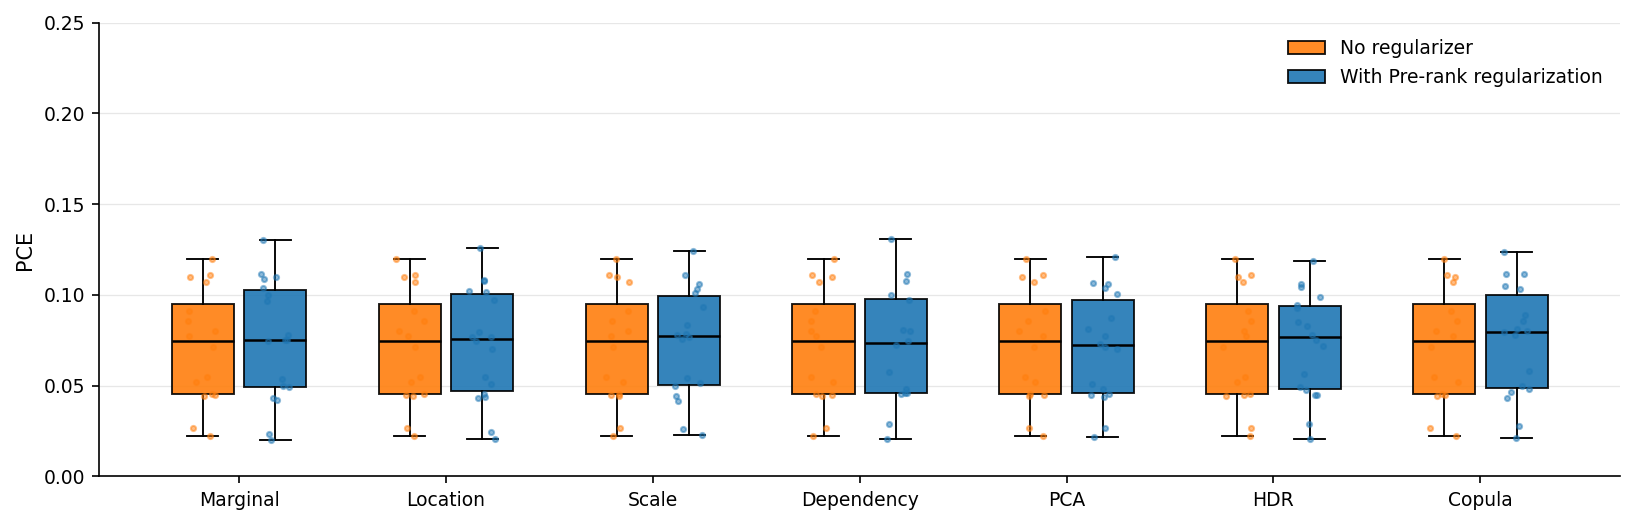

In [108]:
# -----------------------------
# Plot (with points overlaid)
# -----------------------------
# fig, ax = plt.subplots(figsize=(12, 3))

fig, ax = plt.subplots(figsize=(11, 3.6))
x = np.arange(len(order))  # make sure `order` corresponds to the labels

group_width = 0.70
box_width = group_width / len(models)
offsets = np.linspace(-group_width/2 + box_width/2, group_width/2 - box_width/2, len(models))

common_bp = dict(
    widths=0.3,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(linewidth=1.2, color="black"),  # ← black median
    whiskerprops=dict(linewidth=0.9),
    capprops=dict(linewidth=0.9),
)

# draw boxes
bplist = []
for i, m in enumerate(models):
    positions = x + offsets[i]

    bp = ax.boxplot(data_by[m], positions=positions, **common_bp)

    for patch in bp["boxes"]:
        patch.set_alpha(0.9)
        patch.set_linewidth(0.9)
        if m == "without":
            patch.set_facecolor("tab:orange")
        else:
            patch.set_facecolor("tab:blue")

    bplist.append(bp)

# overlay points (jittered)
rng = np.random.default_rng(0)

for i, m in enumerate(models):
    color = "tab:orange" if m == "without" else "tab:blue"
    for j, ys in enumerate(data_by[m]):
        if len(ys) == 0:
            continue
        xs = np.full(len(ys), x[j] + offsets[i])
        xs += (rng.random(len(ys)) - 0.5) * box_width * 0.4  # very light jitter
        ax.scatter(xs, ys, s=6, alpha=0.5, color=color, zorder=3)


# Labels / ticks
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=0)
ax.set_xlabel("")  # keep empty; add caption in paper
ax.set_ylabel("PCE")

# Light horizontal grid for readability
ax.yaxis.grid(True, linewidth=0.6, alpha=0.3)
ax.set_axisbelow(True)

# all_y = np.concatenate([np.concatenate(v) for v in data_by.values() if len(v) and any(len(a) for a in v)])
# ax.set_ylim(np.nanquantile(all_y, 0.02), np.nanquantile(all_y, 0.98))

all_y = np.concatenate(
    [np.concatenate(v) for v in data_by.values() if any(len(a) for a in v)]
)


ymin, ymax = np.nanquantile(all_y, [0.01, 0.99])
pad = 0.1 * (ymax - ymin)
ax.set_ylim(0.0, 0.25)

# ax.set_yscale("log")


# Clean spines (common in papers)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend (use box artists as handles)
handles = [bplist[i]["boxes"][0] for i in range(len(models))]
ax.legend(handles, ["No regularizer", "With Pre-rank regularization"],
          title="", frameon=False, loc="upper right")

fig.tight_layout()

plt.savefig("pce_dependency_boxplot_prerank.pdf", bbox_inches="tight", dpi=300)
plt.show()


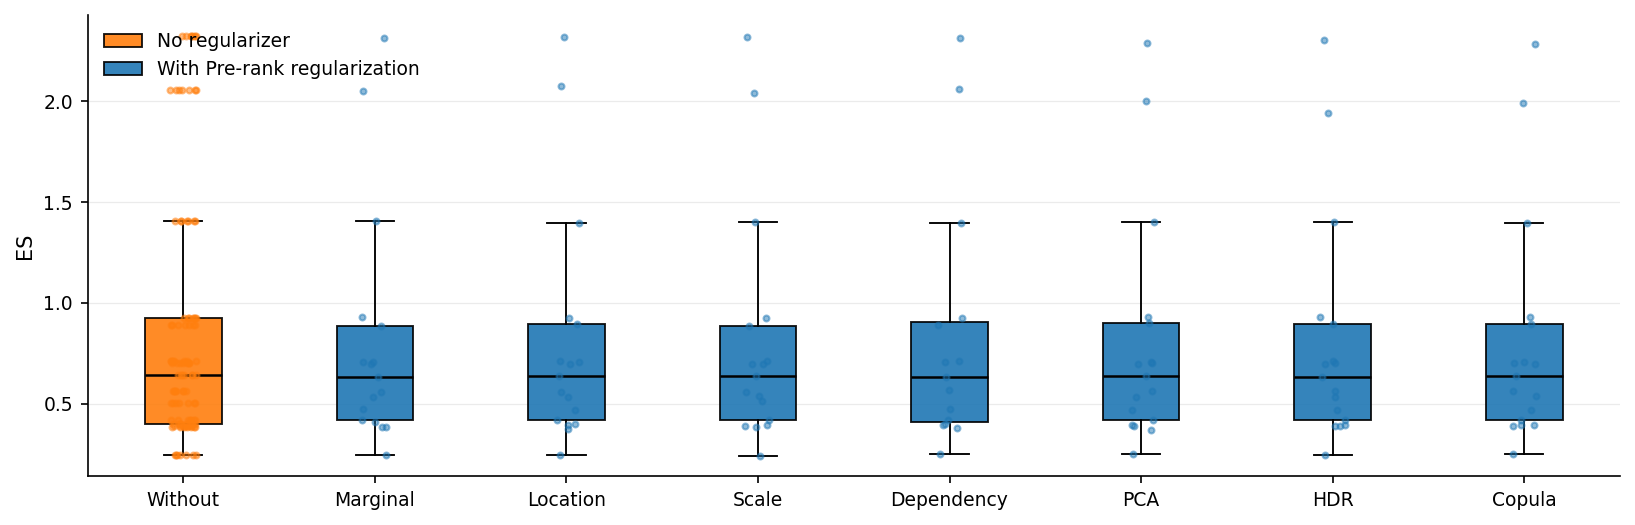

In [53]:
# -----------------------------
# Plot like your example: None + (Marginal, Location, ...)
# -----------------------------
fig, ax = plt.subplots(figsize=(11, 3.6))

baseline = "without"
# pick the prerank model you want (if you only have one "with", use it here)
prerank = next(m for m in models if m != baseline)

labels = ["Without"] + list(order)
x = np.arange(len(labels))

common_bp = dict(
    widths=0.4,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(linewidth=1.2, color="black"),
    whiskerprops=dict(linewidth=0.9),
    capprops=dict(linewidth=0.9),
)

# ----- data -----
without_flat = np.concatenate([a for a in data_by[baseline] if len(a)])
data_plot = [without_flat] + [data_by[prerank][j] for j in range(len(order))]

# ----- draw boxes -----
bp = ax.boxplot(data_plot, positions=x, **common_bp)

# color: baseline orange, all others blue
for i, patch in enumerate(bp["boxes"]):
    patch.set_alpha(0.9)
    patch.set_linewidth(0.9)
    patch.set_facecolor("tab:orange" if i == 0 else "tab:blue")

# ----- overlay points (jittered) -----
rng = np.random.default_rng(0)
for i, ys in enumerate(data_plot):
    if len(ys) == 0:
        continue
    xs = np.full(len(ys), x[i], dtype=float)
    xs += (rng.random(len(ys)) - 0.5) * 0.55 * 0.25  # light jitter
    ax.scatter(xs, ys, s=8, alpha=0.5,
               color=("tab:orange" if i == 0 else "tab:blue"),
               zorder=3)

# ----- labels / ticks -----
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("ES")
ax.yaxis.grid(True, linewidth=0.6, alpha=0.25)
ax.set_axisbelow(True)

# y-lims like before
all_y = np.concatenate([ys for ys in data_plot if len(ys)])
ymin, ymax = np.nanquantile(all_y, [0.02, 0.98])
pad = 0.05 * (ymax - ymin)
ax.set_ylim(ymin - pad, ymax + pad)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# legend (use actual box artists)
ax.legend([bp["boxes"][0], bp["boxes"][1]],
          ["No regularizer", "With Pre-rank regularization"],
          frameon=False, loc="upper left")

fig.tight_layout()
plt.savefig("energy_boxplot_prerank.pdf", bbox_inches="tight", dpi=300)
plt.show()

In [ ]:
# split baseline vs others
baseline = "without"
preranks = [m for m in models if m != baseline]

x = np.arange(len(order))

# offsets only for preranks
group_width = 0.70
box_width = group_width / max(1, len(preranks))
offsets = np.linspace(-group_width/2 + box_width/2, group_width/2 - box_width/2, len(preranks))

# --- baseline once (centered) ---
bp_base = ax.boxplot(data_by[baseline], positions=x, **common_bp)
for patch in bp_base["boxes"]:
    patch.set_alpha(0.9)
    patch.set_linewidth(0.9)
    patch.set_facecolor("tab:orange")

# --- preranks (offset) ---
bplist = []
for i, m in enumerate(preranks):
    positions = x + offsets[i]
    bp = ax.boxplot(data_by[m], positions=positions, **common_bp)
    for patch in bp["boxes"]:
        patch.set_alpha(0.9)
        patch.set_linewidth(0.9)
        patch.set_facecolor("tab:blue")
    bplist.append(bp)

# --- points ---
rng = np.random.default_rng(0)

# baseline points (centered)
for j, ys in enumerate(data_by[baseline]):
    if len(ys) == 0:
        continue
    xs = np.full(len(ys), x[j], dtype=float)
    xs += (rng.random(len(ys)) - 0.5) * box_width * 0.4
    ax.scatter(xs, ys, s=6, alpha=0.5, color="tab:orange", zorder=3)

# prerank points (offset)
for i, m in enumerate(preranks):
    for j, ys in enumerate(data_by[m]):
        if len(ys) == 0:
            continue
        xs = np.full(len(ys), x[j] + offsets[i], dtype=float)
        xs += (rng.random(len(ys)) - 0.5) * box_width * 0.4
        ax.scatter(xs, ys, s=6, alpha=0.5, color="tab:blue", zorder=3)

# legend: baseline + prerank (single label for all preranks)
ax.legend([bp_base["boxes"][0], bplist[0]["boxes"][0]],
          ["No regularizer", "With Pre-rank regularization"],
          frameon=False, loc="upper left")

fig.tight_layout()

# plt.savefig("nll_boxplot_prerank.pdf", bbox_inches="tight", dpi=300)
plt.show()

In [164]:
list(preranks_map.keys())

['mean', 'marginal', 'pca', 'density', 'dependency', 'variance', 'cdf']

In [165]:
# 1) Aggregate in case there are multiple runs per (data_name, prerank)
tmp = (df_total
       .groupby(["data_name", "prerank"], as_index=False)[["pce_pca"]]
       .mean())

# 2) Pivot to get one row per dataset with columns = prerank
wide = tmp.pivot(index="data_name", columns="prerank", values="pce_pca")

# 3) ΔPCE_pca(d) = baseline(without) - PCA-reg(pca)
delta_pca = (wide["without"] - wide["pca"]).dropna()

delta_df = delta_pca.rename("delta_pce_pca").reset_index()  # columns: data_name, delta_pce_pca
delta_df

,data_name,delta_pce_pca
0,air,0.000696
1,bio,0.010486
2,births1,0.001054
3,births2,-0.001413
4,blog_data,-0.001163
5,calcofi,0.002080
6,house,0.001131
7,households,-0.001613
8,meps_19,0.023406
9,meps_20,0.009863


In [169]:
df_total.prerank.unique()

array(['mean', 'marginal', 'pca', 'density', 'dependency', 'variance',
       'cdf', 'without'], dtype=object)

In [166]:
preranks_map = {
    "mean": "Location",
    "marginal": "Marginal",
    "pca": "PCA",
    "density": "HDR",
    "dependency": "Dependency",
    "variance": "Scale",
    "cdf": "Copula"
}

/mnt/default/ipykernel_423430/3240077692.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


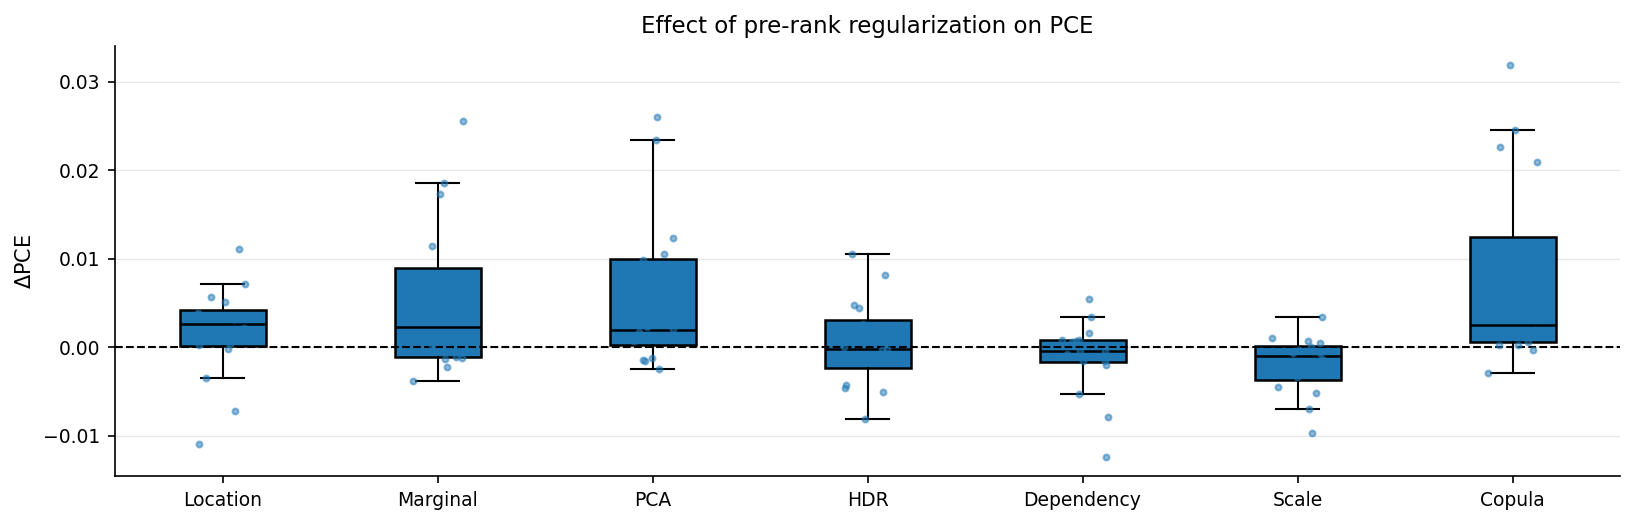

In [ ]:
metric   = "pce_pca"
baseline = "without"
methods  = ["marginal", "mean", "pca", "density", "variance", "dependency", "cdf"]

tmp = (df_total.groupby(["data_name","prerank"], as_index=False)[[metric]].mean())
wide = tmp.pivot(index="data_name", columns="prerank", values=metric)

data = [(wide[baseline] - wide[m]).dropna().values for m in methods]

mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.linewidth": 0.8,
})

fig, ax = plt.subplots(figsize=(11, 3.6))

bp = ax.boxplot(
    data,
    labels=preranks_map.values(),
    patch_artist=True,
    showfliers=False,
    widths=0.4
)

# -----------------------------
# Style boxes and lines
# -----------------------------
box_colors = ["tab:blue"] * len(bp["boxes"])

for box, c in zip(bp["boxes"], box_colors):
    box.set_facecolor(c)
    box.set_linewidth(1.2)

for median in bp["medians"]:
    median.set_linewidth(1.2)
    median.set_color("black")

for whisker in bp["whiskers"]:
    whisker.set_linewidth(1.0)

for cap in bp["caps"]:
    cap.set_linewidth(1.0)

# -----------------------------
# Overlay points (same color as box)
# -----------------------------
rng = np.random.default_rng(0)
box_width = 0.4

for j, (ys, c) in enumerate(zip(data, box_colors), start=1):
    if len(ys) == 0:
        continue
    xs = np.full(len(ys), j, dtype=float)
    xs += (rng.random(len(ys)) - 0.5) * box_width * 0.6
    ax.scatter(xs, ys, s=8, alpha=0.5, color=c, zorder=3)

# -----------------------------
# Axes / cosmetics
# -----------------------------
ax.yaxis.grid(True, linewidth=0.6, alpha=0.3)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.axhline(0, linestyle="--", linewidth=1, color="black")
ax.set_ylabel(r"$\Delta$PCE")
ax.set_title(r"Effect of pre-rank regularization on PCE")

plt.tight_layout()
plt.savefig("Delta_pce_boxplot_prerank.pdf", bbox_inches="tight", dpi=300)
plt.show()